<a href="https://colab.research.google.com/github/leonardobrembilla/mio-progetto-finale/blob/main/LeonardoBrembillaProgettoFinale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PROGETTO FINALE – Start2Impact di Leonardo Brembilla**

# **AIRLINE PASSENGER SATISFACTION**

**Analisi Esplorativa, Machine Learning e Predizione della Soddisfazione dei Passeggeri**

---
# **1. INFORMAZIONI SUL PROGETTO**

**Obiettivo**

L'obiettivo del progetto è costruire un modello di Machine Learning in grado di prevedere la soddisfazione dei passeggeri di una compagnia aerea.

La variabile target è: **satisfaction**, divisa in due classi:

- **satisfied**
- **neutral or dissatisfied**

Si tratta quindi di un problema di: **Classificazione Binaria Supervisonata**.

---
**Dataset utilizzati**

Sono stati forniti due dataset speculari, garantendo il classico split dell'intero pacchetto dati in proporzione 80/20:

A) **Train Set (train.csv)**: **103.904 righe** e **25 colonne**

B) **Test Set (test.csv)**: **25.976 righe** e **25 colonne**

*(Nota metodologica: all'interno del codice, escludendo l'indice iniziale e la variabile target, il parco delle feature predittive di partenza per la Strada 1 è composto da esattamente 22 variabili).*

---
**Descrizione delle variabili**

Le feature analizzate descrivono in modo multidimensionale l'intera esperienza di volo del cliente:

- **Dati anagrafici e di viaggio**: Gender, Customer Type, Age, Type of Travel, Class
- **Dati logistici**: Flight Distance, Departure Delay in Minutes, Arrival Delay in Minutes
- **Valutazione dei servizi (Scale Likert 0-5)**: Inflight wifi service, Departure/Arrival time convenient, Ease of Online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room service, Baggage handling, Checkin service, Inflight service, Cleanliness.

# **2. PREPARAZIONE DEI DATI**

Importazione delle **librerie**.

In [ ]:
# Importazione delle librerie fondamentali per la manipolazione dei dati
import pandas as pd  # Gestione di DataFrame e analisi dati tabulari
import numpy as np   # Operazioni matematiche e gestione di vettori/matrici

# Importazione delle librerie per la visualizzazione grafica dei dati
import matplotlib.pyplot as plt  # Creazione di grafici di base (istogrammi, plot)
import seaborn as sns            # Grafici statistici avanzati (matrici di correlazione, boxplot)

# Importazione degli strumenti per il pre-processing dei dati
from sklearn.preprocessing import LabelEncoder     # Converte variabili categoriali testuali in numeri (0, 1, 2...)
from sklearn.preprocessing import StandardScaler   # Standardizza le feature numeriche (media=0, varianza=1)

# Importazione degli strumenti per la validazione e l'ottimizzazione dei modelli
from sklearn.model_selection import (
    cross_val_score,  # Valuta le performance del modello tramite Cross-Validation
    KFold,            # Divide il dataset in "K" parti per la Cross-Validation
    GridSearchCV,      # Ricerca automatica dei migliori iperparametri del modello
    RandomizedSearchCV   # Ricerca casuale veloce delle combinazioni di iperparametri
)

# Importazione delle metriche per valutare le prestazioni dei modelli di classificazione
from sklearn.metrics import (
    accuracy_score,          # Calcola la percentuale di previsioni corrette
    confusion_matrix,        # Mostra la matrice dei veri positivi/negativi e falsi positivi/negativi
    classification_report,   # Genera un report con Precision, Recall e F1-Score per ogni classe
    roc_auc_score,          # Calcola l'Area Sotto la Curva ROC (AUC)
    roc_curve               # Calcola i punti per tracciare la Curva ROC (TPR e FPR)
)

# Importazione degli algoritmi di Machine Learning basati su Ensemble (Insiemi di alberi)
from sklearn.ensemble import RandomForestClassifier  # Algoritmo Bagging basato su alberi di decisione decisionali
from sklearn.ensemble import AdaBoostClassifier      # Algoritmo Boosting sequenziale per migliorare i classificatori deboli

# Importazione del modello lineare di classificazione
from sklearn.linear_model import LogisticRegression  # Modello di base per la classificazione binaria

# Importazione dei test statistici per la selezione delle feature più importanti
from sklearn.feature_selection import (
    chi2,                 # Test del Chi-Quadrato per valutare l'indipendenza tra variabili categoriali
    mutual_info_classif,  # Calcola l'informazione mutua per misurare la dipendenza non lineare con il target
    f_classif             # Calcola il valore F di ANOVA per feature numeriche rispetto a target categoriali
)


**Caricamento del Dataset da GitHub (Metodo Consigliato)**

Questo metodo permette di **leggere direttamente il file online** senza doverlo caricare manualmente su Google Colab a ogni avvio della sessione. Il file viene ospitato in una **repository pubblica** su GitHub.

**Passaggi eseguiti:**
* Creazione di una **repository pubblica** su GitHub.
* Caricamento del file **titanic_sub.csv**.
* Recupero dell'indirizzo **URL Raw** del file.
* Importazione automatica del dataset in un **DataFrame di Pandas**.

In [ ]:
# Definisce gli URL diretti (Raw) per entrambi i file su GitHub
url_train = "https://raw.githubusercontent.com/Leon56221/mio-progetto-finale/refs/heads/main/train.csv"
url_test = "https://raw.githubusercontent.com/Leon56221/mio-progetto-finale/refs/heads/main/test.csv"

# Scarica i file e li trasforma in due DataFrame distinti
train = pd.read_csv(url_train, encoding='utf-8')
test = pd.read_csv(url_test, encoding='utf-8')

Controlla le **dimensioni dei due dataset** (righe, colonne):

In [ ]:
# Controlla le dimensioni dei due dataset (righe, colonne)
print(f"Dimensioni originarie - Train: {train.shape} | Test: {test.shape}\n")

Dimensioni originarie - Train: (103904, 25) | Test: (25976, 25)



In questa sezione **visualizzo i dataset** in forma tabellare. Per semplicità si mostrano solo le **prime 5 occorrenze**.

In [ ]:
# Mostra le prime 5 righe del train set per capire la struttura visiva dei dati
print("Prime 5 righe del Dataset di Train:")
print(train.head(5))

# Mostra le prime 5 righe del test set per verificarne la corrispondenza con il train
print("\nPrime 5 righe del Dataset di Test:")
print(test.head(5))

Prime 5 righe del Dataset di Train:
   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  2  ...         

In questa sezione **eliminino le colonne inutili** perché sono identificative e non contengono informazione utili:
- **Unnamed: 0**
- **id**

sia dal dataset di **train** che di **test** e apportando le modifiche  sul **DataFrame originale**.

In [ ]:
# Elimina le colonne inutili 'Unnamed: 0' e 'id' dal dataset di train apportando la modifica sul DataFrame originale
train.drop(columns=["Unnamed: 0", "id"], inplace=True)

# Elimina le stesse colonne inutili dal dataset di test apportando la modifica sul DataFrame originale
test.drop(columns=["Unnamed: 0", "id"], inplace=True)

# Controlla le dimensioni dei due dataset (righe, colonne)
print(f"Nuove dimensioni - Train: {train.shape} | Test: {test.shape}\n")

Nuove dimensioni - Train: (103904, 23) | Test: (25976, 23)



Dopo la rimozione, **stampo l'elenco aggiornato** delle colonne per verificare la corretta eliminazione dei dati superflui. In questo modo confermiamo la struttura finale sia del **Train Set** che del **Test Set**.

In [ ]:
# Stampa l'elenco aggiornato delle colonne presenti nel Train Set
print("Colonne rimaste nel Train Set:")
print(train.columns)

# Stampa l'elenco aggiornato delle colonne presenti nel Test Set
print("\nColonne rimaste nel Test Set:")
print(test.columns)

Colonne rimaste nel Train Set:
Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

Colonne rimaste nel Test Set:
Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
  

# **3. EXPLORATORY DATA ANALYSIS (EDA)**

Dopo aver completato la pulizia e la rimozione delle colonne superflue, eseguo l'**analisi descrittiva e informativa** del dataset.

Questa fase è fondamentale per verificare la **coerenza della struttura dei dati** e controllare la **distribuzione statistica** delle variabili numeriche prima di addestrare i modelli di Machine Learning.

**Mostra la struttura** del DataFrame di **Train**: numero di righe, colonne, tipi di dati e **memoria utilizzata**:

In [ ]:
# Stampa un'intestazione per separare visivamente le informazioni del Train Set nel terminale
print("=== [TRAIN] Informazioni sul Dataset (info) ===")

# Mostra la struttura del DataFrame di Train: numero di righe, colonne, tipi di dati e memoria utilizzata
train.info()

# Stampa un'intestazione per separare le statistiche descrittive del Train Set
print("\n=== [TRAIN] Statistiche Descrittive (describe) ===")

# Genera le statistiche descrittive principali delle colonne numeriche del Train (media, deviazione standard, min, max, quartili)
train.describe()

=== [TRAIN] Informazioni sul Dataset (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int6

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Per garantire la massima **consistenza tra i dati**, **eseguo gli stessi controlli informativi e statistici** anche sul **Dataset di Test**. Questo passaggio permette di verificare che le colonne mantengano gli **stessi tipi di dato del train** e che le distribuzioni numeriche siano **coerenti e prive di anomalie**.

In [ ]:
# Stampa un'intestazione per separare visivamente le informazioni del Test Set nel terminale
print("=== [TEST] Informazioni sul Dataset (info) ===")

# Mostra la struttura del DataFrame di Test: verifica tipi di dati, righe e colonne rimanenti
test.info()

# Stampa un'intestazione per separare le statistiche descrittive del Test Set
print("\n=== [TEST] Statistiche Descrittive (describe) ===")

# Calcola e mostra le statistiche principali (media, min, max, ecc.) per le colonne numeriche del Test
print(test.describe())

=== [TEST] Informazioni sul Dataset (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             25976 non-null  object 
 1   Customer Type                      25976 non-null  object 
 2   Age                                25976 non-null  int64  
 3   Type of Travel                     25976 non-null  object 
 4   Class                              25976 non-null  object 
 5   Flight Distance                    25976 non-null  int64  
 6   Inflight wifi service              25976 non-null  int64  
 7   Departure/Arrival time convenient  25976 non-null  int64  
 8   Ease of Online booking             25976 non-null  int64  
 9   Gate location                      25976 non-null  int64  
 10  Food and drink                     25976 non-null  int64  
 11  Online 

**Pulizia e verifica dell'integrità dei dati**

1. Identifico e rimuovo eventuali **righe duplicate** sia nel Train che nel Test per evitare distorsioni nel modello
2. Successivamente, **prima di procedere con l'elaborazione delle feature**, effettuo un controllo dei **valori mancanti** su entrambi i dataset. Identificare la presenza di valori nulli (**NaN**) è un **passaggio obbligatorio**, poiché i modelli di Machine Learning richiedono **matrici di dati complete** per poter eseguire l'addestramento e la fase di test senza errori.

In [ ]:
# Calcola la somma totale delle righe duplicate nel dataset di Train
duplicati_train = train.duplicated().sum()

# Stampa il numero di righe duplicate trovate nel Train
print(f"Righe duplicate nel Train: {duplicati_train}")

# Se vengono trovati duplicati, procedi alla loro rimozione definitiva
if duplicati_train > 0:
    # Applica la rimozione direttamente sul DataFrame originale
    train.drop_duplicates(inplace=True)
    # Conferma l'avvenuta eliminazione a terminale
    print("Righe duplicate rimosse dal Train.")

# Calcola la somma totale delle righe duplicate nel dataset di Test
duplicati_test = test.duplicated().sum()

# Stampa il numero di righe duplicate trovate nel Test
print(f"Righe duplicate nel Test: {duplicati_test}")

# Se vengono trovati duplicati nel Test, procedi alla rimozione
if duplicati_test > 0:
    # Applica la rimozione sul DataFrame originale di Test
    test.drop_duplicates(inplace=True)
    # Informa l'utente del completamento dell'operazione
    print("-> Righe duplicate rimosse con successo dal Test.")

# Stampa un separatore visivo per l'analisi dei valori mancanti nel Train
print("\n--- Valori mancanti nel Dataset di Train ---")

# Conta quanti valori nulli ci sono per ogni colonna del Train
missing_train = train.isnull().sum()

# Filtra e tieni solo le colonne che hanno almeno un valore mancante
missing_train = missing_train[missing_train > 0]

# Verifica se l'elenco delle colonne con valori vuoti non è vuoto
if not missing_train.empty:
    # Mostra l'elenco delle colonne interessate e il rispettivo conteggio
    print(missing_train)
else:
    # Notifica che tutti i dati del Train sono completi
    print("Nessun valore mancante nel Train.")

# Stampa un separatore visivo per l'analisi dei valori mancanti nel Test
print("\n--- Valori mancanti nel Dataset di Test ---")

# Conta quanti valori nulli ci sono per ogni colonna del Test
missing_test = test.isnull().sum()

# Filtra e isola solo le colonne del Test con valori mancanti
missing_test = missing_test[missing_test > 0]

# Controlla se ci sono colonne incomplete nel Test
if not missing_test.empty:
    # Mostra il conteggio dei valori nulli per ogni colonna del Test
    print(missing_test)
else:
    # Notifica che tutti i dati del Test sono completi
    print("Nessun valore mancante nel Test.")

Righe duplicate nel Train: 0
Righe duplicate nel Test: 0

--- Valori mancanti nel Dataset di Train ---
Arrival Delay in Minutes    310
dtype: int64

--- Valori mancanti nel Dataset di Test ---
Arrival Delay in Minutes    83
dtype: int64


Gestione dei valori mancanti tramite imputazione perché i controlli mostrano che l'unica colonna incompleta in entrambi i dataset è **Arrival Delay in Minutes**.

Scelgo di **imputare i valori nulli utilizzando la mediana** calcolata sul dataset di Train.

Questa scelta protegge il modello dall'influenza di eventuali valori estremi (outlier) ed evita il data leakage, applicando la stessa statistica del Train anche al Test Set.

In [ ]:
# Calcolo della mediana della colonna dei ritardi basato sul dataset di Train
median_value = train["Arrival Delay in Minutes"].median()

# Sostituisce i valori nulli nel Train con la mediana calcolata
train["Arrival Delay in Minutes"] = train["Arrival Delay in Minutes"].fillna(median_value)

# Sostituisce i valori nulli nel Test usando la stessa mediana del Train
test["Arrival Delay in Minutes"] = test["Arrival Delay in Minutes"].fillna(median_value)

# Verifica visiva immediata del risultato
nulli_train = train['Arrival Delay in Minutes'].isnull().sum()
nulli_test = test['Arrival Delay in Minutes'].isnull().sum()
print(f"Valori nulli rimasti in 'Arrival Delay in Minutes' -> Train: {nulli_train} | Test: {nulli_test}\n")

Valori nulli rimasti in 'Arrival Delay in Minutes' -> Train: 0 | Test: 0



**Codifica e analisi della variabile target**
1. converto la variabile obiettivo **satisfaction** da valori testuali a binari (**0 e 1**), associando lo zero alla neutralità o insoddisfazione e l'uno alla soddisfazione
2. Successivamente, analizzo la **distribuzione delle classi** in termini assoluti e percentuali su entrambi i dataset per verificare se il target risulta bilanciato

In [ ]:
# Definisce il dizionario per mappare i valori testuali in valori numerici binari
mappa_target = {'neutral or dissatisfied': 0, 'satisfied': 1}

# Applica la codifica binaria sulla colonna target del dataset di Train
train['satisfaction'] = train['satisfaction'].map(mappa_target)

# Applica la stessa codifica binaria sulla colonna target del dataset di Test
test['satisfaction'] = test['satisfaction'].map(mappa_target)

# Stampa un'intestazione per l'analisi dei conteggi assoluti nel Train Set
print("=== DISTRIBUZIONE TARGET NEL TRAIN SET (0 = Insoddisfatto, 1 = Soddisfatto) ===")

# Conta quanti record appartengono a ciascuna classe nel dataset di Train
print(train["satisfaction"].value_counts())

# Stampa un separatore per l'analisi delle percentuali nel Train Set
print("\nPercentuali nel Train Set:")

# Calcola le frequenze relative e le trasforma in percentuali per il Train
print(train["satisfaction"].value_counts(normalize=True) * 100)

# Stampa un'intestazione per l'analisi dei conteggi assoluti nel Test Set
print("\n=== DISTRIBUZIONE TARGET NEL TEST SET (0 = Insoddisfatto, 1 = Soddisfatto) ===")

# Conta quanti record appartengono a ciascuna classe nel dataset di Test
print(test["satisfaction"].value_counts())

# Stampa un separatore per l'analisi delle percentuali nel Test Set
print("\nPercentuali nel Test Set:")

# Calcola le frequenze relative e le trasforma in percentuali per il Test
print(test["satisfaction"].value_counts(normalize=True) * 100)

=== DISTRIBUZIONE TARGET NEL TRAIN SET (0 = Insoddisfatto, 1 = Soddisfatto) ===
satisfaction
0    58879
1    45025
Name: count, dtype: int64

Percentuali nel Train Set:
satisfaction
0    56.666731
1    43.333269
Name: proportion, dtype: float64

=== DISTRIBUZIONE TARGET NEL TEST SET (0 = Insoddisfatto, 1 = Soddisfatto) ===
satisfaction
0    14573
1    11403
Name: count, dtype: int64

Percentuali nel Test Set:
satisfaction
0    56.101786
1    43.898214
Name: proportion, dtype: float64


**I risultati dell'output confermano un'ottima struttura dei dati** per il proseguimento del progetto, evidenziando due aspetti fondamentali:
- **Dataset ben bilanciato**: la presenza di circa il **56% di passeggeri insoddisfatti (0)** e il **43-44% di soddisfatti (1)** rappresenta una proporzione ideale. I modelli di Machine Learning potranno apprendere le caratteristiche di entrambe le categorie in modo equo e senza pregiudizi algoritmici
- **Perfetta coerenza tra Train e Test**: le percentuali nel **Train Set (56.6% vs 43.3%)** rispecchiano quasi fedelmente quelle del **Test Set (56.1% vs 43.8%)**. Questa stabilità dimostra che la suddivisione (splitting) dei dati è corretta e priva di distorsioni campionarie

**Implicazioni per la modellazione**:
- **Nessun ricampionamento**: data l'assenza di sbilanciamento critico, **NON è necessario** applicare tecniche correttive come SMOTE, Random Oversampling o Undersampling
- **Scelta delle metriche**: la metrica dell'**Accuracy Score** sarà pienamente affidabile e rappresentativa per valutare le performance globali dei modelli, sebbene verrà affiancata da Precision, Recall e AUC-ROC per una validazione completa

**Analisi e rilevamento degli outlier**: esamino le sole variabili numeriche continue per identificare la presenza di valori anomali (outlier) attraverso il **metodo dell'Intervallo Interquartile (IQR)**.

Calcolando i limiti inferiore e superiore per ciascuna feature, quantifico l'impatto complessivo di questi valori rispetto all'intera matrice dei dati numerici, valutando se sia necessaria una successiva fase di rimozione o trasformazione.

In [ ]:
# Definisce la lista delle sole colonne numeriche continue su cui calcolare gli outlier
colonne_numeriche = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

# Inizializza il contatore per accumulare il numero totale di outlier trovati
outlier_totali = 0

# Calcola il numero massimo teorico di punti dato dal prodotto tra righe e colonne considerate
totale_record = len(train) * len(colonne_numeriche)

# Avvia un ciclo per analizzare singolarmente ogni colonna numerica specificata
for col in colonne_numeriche:
    # Calcola il primo quartile (25° percentile) della colonna corrente
    Q1 = train[col].quantile(0.25)

    # Calcola il terzo quartile (75° percentile) della colonna corrente
    Q3 = train[col].quantile(0.75)

    # Calcola l'ampiezza dell'intervallo interquartile (IQR)
    IQR = Q3 - Q1

    # Determina la soglia limite inferiore oltre la quale un valore è considerato outlier
    inf = Q1 - 1.5 * IQR

    # Determina la soglia limite superiore oltre la quale un valore è considerato outlier
    sup = Q3 + 1.5 * IQR

    # Conta quante righe contengono valori al di fuori delle soglie minime e massime
    n_outliers = train[(train[col] < inf) | (train[col] > sup)].shape[0]

    # Somma il numero di outlier trovati in questa colonna al contatore complessivo
    outlier_totali += n_outliers

# Calcola l'incidenza percentuale degli outlier sul totale complessivo dei dati esaminati
percentuale_outlier = (outlier_totali / totale_record) * 100

# Stampa a terminale la percentuale globale formattata con due cifre decimali
print(f"Percentuale complessiva di outlier nei dati numerici: {percentuale_outlier:.2f}%")

Percentuale complessiva di outlier nei dati numerici: 7.40%


**Conclusioni sull'Analisi degli Outlier**: **Il calcolo evidenzia un'incidenza complessiva di valori anomali pari al 7.40%** sul totale dei punti dato esaminati nelle variabili numeriche continue.

Si è scelto di **NON rimuovere o modificar** questi dati per due ragioni fondamentali:
1. **Robustezza intrinseca dei Modelli:** Gli algoritmi principali selezionati per il progetto (*Random Forest* e *AdaBoost*) si basano su insiemi di alberi decisionali. Queste architetture sono nativamente resistenti agli outlier, poiché isolano i valori estremi nei nodi terminali senza distorcere le regole di split generali del dataset
2. **Rilevanza del dominio di business**: nel contesto del trasporto aereo, un forte ritardo alla partenza o all'arrivo non è un errore di tracciamento, ma un evento reale. Esso rappresenta spesso la causa primaria dell'insoddisfazione del cliente; eliminare o alterare questi record priverebbe i modelli dell'informazione predittiva più preziosa



**Codifica delle feature categoriche e verifica dei tipi**

Converto le restanti variabili categoriche di input:
- **Gender**
- **Customer Type**
- **Type of Travel**
- **Class**

in valori numerici utilizzando il **Label Encoding**. Questo passaggio permette di mappare i testi in etichette intere, garantendo la compatibilità con i modelli di machine learning.

Al termine, eseguo una **verifica finale dei tipi di dati** per assicurarci che la trasformazione sia andata a buon fine su tutte le colonne coinvolte, inclusa la variabile target **satisfaction**.



In [ ]:
# Definisce la lista delle restanti colonne categoriche di testo da convertire
categorical_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# Inizializza l'istanza di LabelEncoder per la conversione in numeri interi
le = LabelEncoder()

# Avvia un ciclo per codificare singolarmente ogni colonna categorica identificata
for col in categorical_columns:
    # Calcola la codifica sul dataset di Train e la applica direttamente alla colonna
    train[col] = le.fit_transform(train[col])

    # Applica la stessa codifica sul dataset di Test per mantenere la consistenza
    test[col] = le.transform(test[col])

# Stampa un'intestazione per mostrare l'esito del controllo sui tipi di dato nel Train
print("--- Verifica finale dei tipi di dati nel Train ---")

# Mostra il tipo di dato (dtype) delle colonne appena codificate e della variabile target
print(train[categorical_columns + ['satisfaction']].dtypes)

--- Verifica finale dei tipi di dati nel Train ---
Gender            int64
Customer Type     int64
Type of Travel    int64
Class             int64
satisfaction      int64
dtype: object


**L'output della verifica conferma il successo della fase di pre-processing e codifica**: tutte le variabili categoriche (**Gender, Customer Type, Type of Travel, Class**) e la variabile target (**satisfaction**) sono state correttamente trasformate in tipi di dati numerici interi (**int64**).

**Separazione delle feature e del target**: **isolo la variabile obiettivo satisfaction dalle variabili predittive (feature) sia per il dataset di Train che per quello di Test**. Questa operazione genera le matrici degli input X e i vettori dei target y, strutturando i dati nella forma standard richiesta per l'addestramento e la validazione dei modelli di machine learning.

In [ ]:
# Rimuove la colonna target dal Train per isolare le sole variabili predittive
X_train = train.drop(columns=['satisfaction'])

# Isola la colonna target del Train nel rispettivo vettore delle etichette
y_train = train['satisfaction']

# Rimuove la colonna target dal Test per isolare le sole variabili predittive
X_test = test.drop(columns=['satisfaction'])

# Isola la colonna target del Test nel rispettivo vettore delle etichette
y_test = test['satisfaction']

# Stampa un'intestazione per confermare visivamente l'avvenuto split dei dataset
print("=== SPLIT EFFETTUATO CON SUCCESSO ===")

# Mostra le dimensioni della matrice delle feature del Train Set (righe, colonne)
print(f"X_train (Variabili di addestramento): {X_train.shape}")

# Mostra la lunghezza del vettore target del Train Set (numero di righe)
print(f"y_train (Target di addestramento):    {y_train.shape}")

# Mostra le dimensioni della matrice delle feature del Test Set (righe, colonne)
print(f"X_test  (Variabili di test):         {X_test.shape}")

# Mostra la lunghezza del vettore target del Test Set (numero di righe)
print(f"y_test  (Target di test):            {y_test.shape}")

=== SPLIT EFFETTUATO CON SUCCESSO ===
X_train (Variabili di addestramento): (103904, 22)
y_train (Target di addestramento):    (103904,)
X_test  (Variabili di test):         (25976, 22)
y_test  (Target di test):            (25976,)


**I risultati a terminale confermano la corretta formattazione geometrica dei dati**: le matrici delle feature e i vettori target mantengono una perfetta coerenza strutturale. Nello specifico, il **dataset di Train conta 103.904 campioni** e quello di **Test 25.976 campioni**, mantenendo lo stesso numero fisso di variabili predittive (**22 feature**).

**Standardizzazione delle feature**: applico lo **StandardScaler** per normalizzare la scala di tutte le variabili numeriche continue e delle etichette codificate.

Questa trasformazione ridimensiona i dati in modo che abbiano **media pari a 0 e deviazione standard uguale a 1**, garantendo che nessuna feature domini artificialmente sulle altre a causa della sua scala originaria.

**La standardizzazione non viene applicata alla target**, che deve mantenere la sua natura binaria (0 e 1). Calcolo i parametri di scaling esclusivamente sul Train Set per prevenire il data leakage e li applichiamo in seguito al Test Set, assicurando così che tutte le variabili contribuiscano in modo equo all'addestramento del modello.

In [ ]:
# Inizializza l'istanza di StandardScaler per la normalizzazione dei dati
scaler = StandardScaler()

# Calcola media e deviazione standard sul Train e trasforma la matrice delle feature
X_train_scaled = scaler.fit_transform(X_train)

# Applica la stessa trasformazione al Test Set usando i parametri appresi dal Train
X_test_scaled = scaler.transform(X_test)

# Stampa un messaggio di conferma per l'avvenuto completamento dello scaling
print("=== OPERAZIONE COMPLETATA CON SUCCESSO ===")

# Mostra la forma finale della matrice delle feature scalate per il Train Set
print(f"X_train_scaled pronto! Forma: {X_train_scaled.shape}")

# Mostra la forma finale della matrice delle feature scalate per il Test Set
print(f"X_test_scaled pronto!  Forma: {X_test_scaled.shape}")

=== OPERAZIONE COMPLETATA CON SUCCESSO ===
X_train_scaled pronto! Forma: (103904, 22)
X_test_scaled pronto!  Forma: (25976, 22)


**La verifica finale conferma il perfetto esito del processo di scaling**: le nuove matrici **X_train_scaled (103.904 campioni)** e **X_test_scaled (25.976 campioni)** mantengono inalterata la struttura a **22 colonne**, indicando che i dati sono stati trasformati correttamente senza alcuna perdita di informazioni o alterazione geometrica.

**Analisi delle correlazioni lineari**: genero una mappa di calore (**heatmap**) per visualizzare la **matrice di correlazione di Pearson** tra tutte le variabili numeriche del Train Set.

Questo controllo grafico è fondamentale per **identificare eventuali problemi di multicollinearità** (variabili troppo correlate tra loro che potrebbero confondere alcuni modelli) e per esaminare la forza delle relazioni lineari tra i predittori e la variabile target.

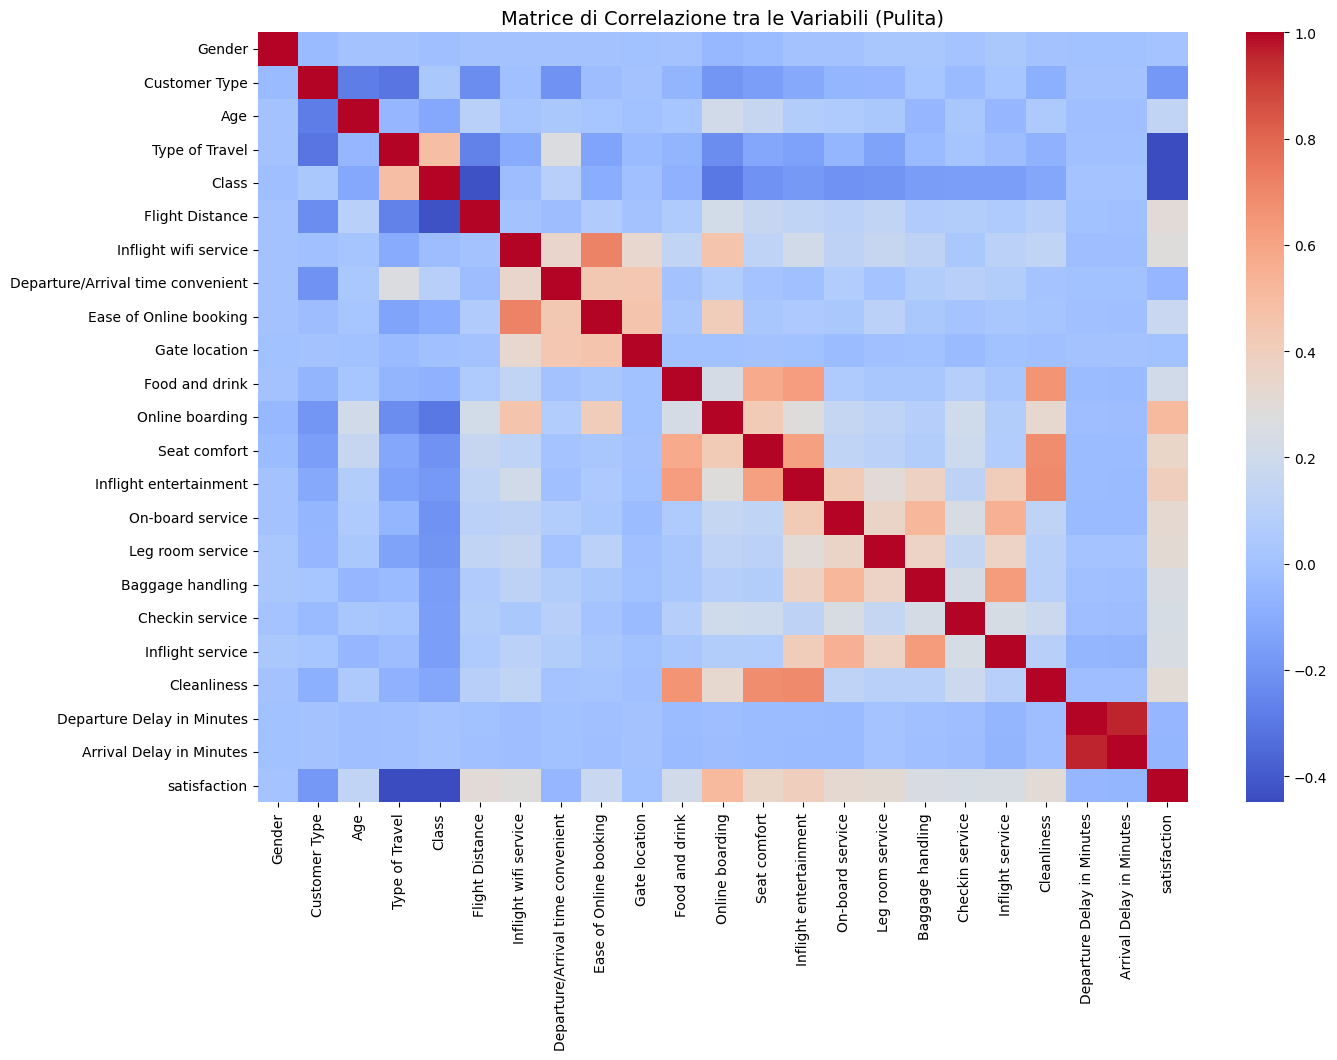

In [ ]:
# Inizializza la figura impostando le dimensioni del grafico (larghezza, altezza) in pollici
plt.figure(figsize=(15, 10))

# Genera la heatmap calcolando la correlazione solo sulle colonne numeriche del Train
# Usa la mappa di colore 'coolwarm' (blu freddo per correlazioni negative, rosso caldo per positive)
# L'argomento annot=False evita di stampare i valori numerici in ogni cella per rendere il grafico più pulito
sns.heatmap(train.corr(numeric_only=True), cmap="coolwarm", annot=False)

# Aggiunge il titolo principale al grafico specificando la dimensione del carattere
plt.title("Matrice di Correlazione tra le Variabili (Pulita)", fontsize=14)

# Renderizza e mostra visivamente il grafico a schermo
plt.show()

Dall'immagine della heatmap si possono confermare **tre dinamiche chiave**:

- **Forte multicollinearità** (in basso a destra): L'incrocio tra **Departure Delay in Minutes** e **Arrival Delay in Minutes** è un quadrato rosso vivo. I due ritardi dicono quasi la stessa cosa.
- **I fattori di successo (riga satisfaction)**: Le caselle più arancioni indicano che l' **Online boarding** (imbarco online) e **Inflight entertainment** (intrattenimento a bordo) sono i servizi che spingono di più i passeggeri a essere soddisfatti.
- **I fattori di insoddisfazione** (quadrati blu): Le classi economiche (**Class**) e i viaggi personali (**Type of Travel**) hanno una **correlazione negativa evidente** con la soddisfazione.

**Focus sulle Relazioni con la Soddisfazione**

1. **Correlazioni Positive** (variabili che crescono insieme alla soddisfazione):
- **Online Boarding**: Semplificare la procedure dell'imbarco riduce lo stress iniziale del viaggio
- **Inflight Entertainment & Seat Comfort**: Un sedile comodo e la TV a bordo rendono piacevole l'esperienza del volo
2. **Correlazioni Negative** (variabili associate all'insoddisfazione):
- **Type of Travel & Class**: come evidenziato dalle caselle blu sul grafico, chi viaggia per **motivi personali** o si trova nelle **classi economiche** tende a essere molto più insoddisfatto rispetto a chi vola in Business per lavoro

Questo script serve a **identificare ed estrarre le coppie di variabili altamente correlate** (con un coefficiente di correlazione **maggiore di 0.90**).

Trovare queste relazioni è fondamentale nella fase di pulizia dei dati per **evitare la multicollinearità**, un problema che può distorcere i risultati dei modelli predittivi e **gonfiare artificialmente la varianza** delle stime.

Esaminando solo la **triangolare superiore** della matrice, il codice evita di analizzare i duplicati e le correlazioni delle variabili con se stesse.

In [ ]:
# Calcola la matrice di correlazione lineare (Pearson) tra tutte le variabili numeriche.
# Applica .abs() per trasformare tutti i valori in positivi, considerando l'intensità del legame
# indipendentemente dal fatto che la correlazione sia positiva o negativa
corr_matrix = train.corr(numeric_only=True).abs()

# Crea una maschera booleana usando np.triu per isolare la parte triangolare superiore
# (escludendo la diagonale principale grazie a k=1).
# Applica questa maschera alla matrice di correlazione: i valori della metà inferiore diventano NaN
# Questo serve a evitare di controllare due volte la stessa coppia di variabili (es. A con B e B con A)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Utilizza una list comprehension per scorrere tutte le celle della matrice triangolare superiore
# Filtra le celle che non sono vuote (NaN) e che mostrano un valore di correlazione strettamente superiore a 0.90
# Salva il risultato sotto forma di una lista di tuple: (Variabile_1, Variabile_2, Valore_Correlazione)
high_corr = [
    (column, row, upper.loc[row, column])
    for column in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, column]) and upper.loc[row, column] > 0.90
]

# Stampa un'intestazione testuale per i risultati
print("Feature altamente correlate:")

# Cicla all'interno della lista 'high_corr' e mostra a schermo ogni singola coppia individuata con il rispettivo valore
for pair in high_corr:
    print(pair)

Feature altamente correlate:
('Arrival Delay in Minutes', 'Departure Delay in Minutes', np.float64(0.9602470986642783))


Non sono presenti correlazioni perfette pari a 1. Le correlazioni più elevate riguardano **Departure Delay e Arrival Delay**, ma rimangono **sotto la soglia di perfetta ridondanza**.

Il risultato mostra una **fortissima correlazione lineare positiva (pari a circa 0.96)** tra il Departure Delay in Minutes e il Arrival Delay in Minutes dei voli.
- **Multicollinearità quasi perfetta**: Le due variabili contengono quasi la **stessa identica informazione**. Quando un volo parte in ritardo, è matematicamente e logicamente certo che arriverà in ritardo della stessa identica entità (salvo rari recuperi in volo)


**Analisi quantitativa della multicollinearità**: calcolo la matrice di correlazione in **valore assoluto** per isolare l'intensità delle relazioni lineari indipendentemente dal loro segno (+ o -).

Azzerando la diagonale principale per escludere l'autocorrelazione di ciascuna variabile con se stessa, estraiamo il **valore massimo di correlazione** che ogni feature ha con un'altra colonna del dataset. Questo controllo numerico ci permette di identificare con precisione chirurgica le coppie di variabili ridondanti.

In [ ]:
# Calcola la matrice di correlazione lineare (Pearson) prendendo solo i valori assoluti
# Questo serve a valutare la forza della relazione, sia essa positiva o negativa
corr_matrix = train.corr(numeric_only=True).abs()

# Sostituisce i valori della diagonale principale (tutti pari a 1.0) con degli zeri
# Operazione necessaria per evitare che una variabile risulti massimamente correlata con se stessa
np.fill_diagonal(corr_matrix.values, 0)

# Stampa un'intestazione per l'output nel terminale relativo alla multicollinearità
print("=== VERIFICA MULTICOLLINEARITÀ (Correlazione Massima con altre Feature) ===")

# Trova il valore massimo di correlazione per ciascuna feature rispetto a tutte le altre
# Ordina i risultati in modo decrescente (dal valore più alto a quello più basso) e li stampa
print(corr_matrix.max().sort_values(ascending=False))

=== VERIFICA MULTICOLLINEARITÀ (Correlazione Massima con altre Feature) ===
Departure Delay in Minutes           0.960247
Arrival Delay in Minutes             0.960247
Inflight wifi service                0.715856
Ease of Online booking               0.715856
Inflight entertainment               0.691815
Cleanliness                          0.691815
Seat comfort                         0.678534
Food and drink                       0.657760
Baggage handling                     0.628561
Inflight service                     0.628561
On-board service                     0.550782
Online boarding                      0.503557
satisfaction                         0.503557
Class                                0.487088
Type of Travel                       0.487088
Gate location                        0.458655
Departure/Arrival time convenient    0.444757
Flight Distance                      0.427219
Leg room service                     0.369544
Customer Type                        0.308333
Age 

**Analisi dei Risultati Critici**

1. **La coppia dei ritardi (Criticità elevate)**: **Departure Delay in Minutes** e **Arrival Delay in Minutes** hanno una **correlazione reciproca del 96% (0.96)**. Di fatto sono quasi fotocopie. Nei modelli lineari, mantenere entrambe le variabili può **destabilizzare gravemente i coefficienti**
2. **La coppia dei servizi digitali (Correlazione Moderata)**: **Ease of Online booking** e **Inflight wifi service** hanno una **correlazione del 71.5% (0.715)**. Questo indica che l'esperienza digitale a bordo è fortemente legata alla percezione della facilità di gestione della prenotazione online
3. **Allineamento dei servizi di bordo**: si nota una connessione rilevante (**69.18%**) anche tra **Inflight entertainment** e **Cleanliness**, a dimostrazione di come il comfort visivo e l'igiene della cabina viaggino di pari passo nella percezione del passeggero

Dall'analisi delle correlazioni massime emerge una **forte multicollinearità** tra:
* **Departure Delay** e **Arrival Delay** ($r = 0.965$).

**Scelta strategica per la modellazione:** Poiché gli algoritmi scelti per la fase successiva sono **modelli ad albero** (Random Forest e AdaBoost), questa collinearità **non influirà negativamente** sulla capacità predittiva complessiva. Possiamo quindi procedere mantenendo intatta la struttura delle feature.


**Feature Selection**

La traccia richiede:

1. **Chi-Square**
2. **Mutual Information**
3. **T-Test (ANOVA F-test)**

**1. Chi-Square**

Selezione delle feature tramite test del Chi-Quadrato: applico il test statistico del **Chi-Quadrato** sulle **sole variabili categoriche e discrete del dataset per valutarne il grado di indipendenza rispetto alla variabile target satisfaction**.

Questo metodo quantifica la forza dell'associazione tra ciascun predittore discreto e l'output binarizzato; **punteggi di Chi2 Score più elevati indicano una maggiore capacità informativa della feature**, aiutando a stabilire una gerarchia oggettiva sull'importanza dei servizi percepiti dai passeggeri.

In [ ]:
# Crea un sottoinsieme del Train Set eliminando le variabili numeriche continue
# Il test del Chi-Quadrato richiede infatti feature categoriche o conteggi discreti non negativi
colonne_continue = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
X_train_discrete = X_train.drop(columns=colonne_continue)

# Esegue il test del Chi-Quadrato confrontando la matrice discreta con il vettore target
# La funzione chi2 restituisce i punteggi statistici (scores) e i rispettivi p-value
scores, p_values = chi2(X_train_discrete, y_train)

# Struttura i vettori ottenuti in un DataFrame per facilitare la lettura e la manipolazione
df_chi2 = pd.DataFrame({
    'Feature': X_train_discrete.columns,
    'Chi2 Score': scores,
    'p-value': p_values
})

# Stampa un'intestazione per l'output a terminale dedicato alla Feature Selection
print("=== FEATURE SELECTION: CHI-SQUARE TEST ===")

# Ordina il DataFrame in base al punteggio del Chi-Quadrato in modalità decrescente
# Converte in stringa nascondendo l'indice numerico di riga per una visualizzazione pulita
print(df_chi2.sort_values(by='Chi2 Score', ascending=False).to_string(index=False))

=== FEATURE SELECTION: CHI-SQUARE TEST ===
                          Feature   Chi2 Score      p-value
                  Online boarding 14761.957221 0.000000e+00
                   Type of Travel 14445.748601 0.000000e+00
                            Class 13606.876336 0.000000e+00
           Inflight entertainment  8711.181948 0.000000e+00
                     Seat comfort  6419.260324 0.000000e+00
            Inflight wifi service  5422.333982 0.000000e+00
                 On-board service  5299.337352 0.000000e+00
                 Leg room service  5261.976617 0.000000e+00
                      Cleanliness  5071.376389 0.000000e+00
                    Customer Type  2989.976064 0.000000e+00
                  Checkin service  2808.444759 0.000000e+00
                   Food and drink  2527.913233 0.000000e+00
                 Baggage handling  2448.815383 0.000000e+00
                 Inflight service  2362.946754 0.000000e+00
           Ease of Online booking  2174.524945 0.000000e+

**Analisi e Interpretazione del Chi-Square Test**

1. **I Top Predictor (Punteggi più alti)**: In cima alla classifica troviamo le feature con il **Chi2 Score più elevato in assoluto**. Sono i fattori che influenzano maggiormente la scelta del passeggero:
- **Online boarding** (~14.762)
- **Type of Travel** (~14.445)
- **Class** (~13.606)
- **Inflight entertainment** (~8.711)

Questo **conferma matematicamente** quanto avevo intuito a livello grafico: la tipologia di viaggio, la classe di volo e la facilità di imbarco online sono le **colonne portanti della soddisfazione del cliente**.

2. **Analisi dei p-value (Significatività Statistica)**

- Per quasi tutte le variabili, il **p-value è pari a 0.000000e+00**. In statistica, un **valore inferiore a 0.05** indica che la relazione non è casuale. Essendo praticamente zero, significa che queste feature hanno un legame indissolubile e ad **altissima significatività con il target**.
- Il **Gender** (Genere) ha un **punteggio molto basso** (~7.86) e un **p-value di ~0.005**. È comunque statisticamente significativo, ma ha un **impatto minimo** sulla soddisfazione complessiva.

3. **La variabile staticamente irrilevante**: Guardando l'ultima riga dell'output, **Gate location** ha un **Chi2 Score estremamente ridotto (~0.026) e un p-value altissimo di 0.87** (molto maggiore rispetto alla soglia critica di 0.05).
- **Interpretazione strategica**: la posizione geografica del gate in aeroporto non ha alcuna relazione con la soddisfazione finale del passeggero. Si tratta di una **variabile statisticamente irrilevante** poiché indipendente rispetto al target, che potrebbe essere ignorata o scartata senza perdere potere predittivo.

**2. Mutual Information**

**Selezione delle feature tramite Informazione Mutua**: applico l'**algoritmo di Mutual Information (Informazione Mutua)** su tutte le variabili del Train Set per misurare la quantità di informazione che ciascun predittore condivide con il target **satisfaction**.

A differenza dei test lineari o del Chi-Quadrato, questo metodo non parametrico è in grado di **catturare qualsiasi tipo di relazione, comprese quelle non lineari e complesse**, sia per variabili continue che discrete.

Un punteggio di MI Score pari a 0 indica che la feature è completamente indipendente rispetto alla variabile obiettivo.

In [ ]:
# Calcola i punteggi di Informazione Mutua tra la matrice delle feature e il target
# Il parametro random_state=42 assicura che i risultati siano perfettamente riproducibili
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# Struttura i risultati ottenuti in un DataFrame per renderli facilmente leggibili
df_mi = pd.DataFrame({
    'Feature': X_train.columns,
    'MI Score': mi_scores
})

# Ordina le feature in base al punteggio MI Score dal valore più alto a quello più basso
df_mi = df_mi.sort_values(by='MI Score', ascending=False)

# Stampa un'intestazione per l'output nel terminale dedicato alla Feature Selection
print("=== FEATURE SELECTION: MUTUAL INFORMATION ===")

# Mostra a schermo la tabella completa formattata e priva degli indici di riga
print(df_mi.to_string(index=False))

=== FEATURE SELECTION: MUTUAL INFORMATION ===
                          Feature  MI Score
                  Online boarding  0.212467
            Inflight wifi service  0.161353
                            Class  0.139110
                   Type of Travel  0.118244
           Inflight entertainment  0.096520
                     Seat comfort  0.085367
                  Flight Distance  0.065787
                 Leg room service  0.064208
                 On-board service  0.060573
                      Cleanliness  0.058157
           Ease of Online booking  0.053479
                              Age  0.046408
                 Inflight service  0.044784
                 Baggage handling  0.043516
                  Checkin service  0.034365
                   Food and drink  0.026770
                    Customer Type  0.021051
                    Gate location  0.016411
                           Gender  0.009111
         Arrival Delay in Minutes  0.007805
       Departure Delay in Minu

**Analisi e Interpretazione della Mutual Information**

1. **Coerenza con il Chi-Square (I Top Feature)**
- Il risultato conferma l'estrema importanza di **Online boarding** (primo posto fisso con con un **MI Score di 0.212**), seguito da **Inflight wifi service**, **Class** e **Type of Travel**. Questo allineamento tra test statistici differenti irrobustisce la tesi iniziale: queste variabili rappresentano i **pilastri informativi fondamentali** per qualsiasi modello predittivo.

2. **Il comportamento delle variabili continue**
- **Flight Distance (0.065)** e **Age (0.046)** mostrano un **impatto moderato**. Questo significa che la lunghezza del viaggio e l'età del passeggero contengono pattern utili a tracciare i profili di soddisfazione
- **I ritardi** (**Arrival Delay in Minutes** e **Departure Delay in Minutes**) si trovano in fondo alla classifica con **valori molto bassi (~0.007)**. **Nota sulla relazione**: questo comportamento non significa che i ritardi non contino in assoluto, ma poiché la stragrande maggioranza dei voli ha **0 minuti di ritardo**, l'informazione mutua globale calcolata sull'intero campione risulta matematicamente schiacciata verso lo zero.

3. **I fanalini di coda**
- Le variabili **Gender (0.009)** e **Gate location (0.016)** si confermano quasi del tutto **irrilevanti** anche per questo test non parametrico, validando ulteriormente la loro scarsa utilità nella separazione delle classi di target



**3. T-Test (ANOVA F-test)**

**Selezione delle feature tramite test ANOVA F-Test**: applico il test statistico **ANOVA (Analysis of Variance) F-Test** sulle sole variabili numeriche continue del dataset per verificare se le loro medie differiscono in modo significativo tra i due gruppi di target (**satisfaction** pari a 0 o 1).

Questo metodo valuta la varianza tra i gruppi rispetto alla varianza interna a ciascun gruppo; valori di **F-Statistic** più elevati indicano che la variabile continua ha un **forte potere discriminante** ed è in grado di separare efficacemente i passeggeri soddisfatti da quelli insoddisfatti.

In [ ]:
# Isola unicamente le variabili numeriche continue dal dataset di addestramento
# Il test ANOVA F-Test è specifico per valutare l'impatto di predittori continui su un target categorico
colonne_continue = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
X_train_continuous = X_train[colonne_continue]

# Esegue il calcolo dell'ANOVA F-Test confrontando le feature continue con il target
# La funzione f_classif restituisce i valori della statistica F (f_scores) e i rispettivi p-value
f_scores, p_values_anova = f_classif(X_train_continuous, y_train)

# Inserisce i vettori calcolati in un DataFrame per strutturare l'output in modo tabellare
df_anova = pd.DataFrame({
    'Feature': colonne_continue,
    'F-Statistic': f_scores,
    'p-value': p_values_anova
})

# Stampa l'intestazione della sezione dedicata alla Feature Selection con ANOVA
print("=== FEATURE SELECTION: ANOVA F-TEST ===")

# Ordina il DataFrame in base al valore della statistica F in ordine decrescente
# Mostra il risultato a terminale nascondendo l'indice di riga per una migliore pulizia visiva
print(df_anova.sort_values(by='F-Statistic', ascending=False).to_string(index=False))

=== FEATURE SELECTION: ANOVA F-TEST ===
                   Feature  F-Statistic      p-value
           Flight Distance 10184.421915 0.000000e+00
                       Age  1992.389117 0.000000e+00
  Arrival Delay in Minutes   343.887980 1.208293e-76
Departure Delay in Minutes   265.592493 1.229346e-59


**Analisi e Interpretazione dell'ANOVA F-Test**

1. **La distanza del volo è dominante**
- La variabile **Flight Distance** ha una statistica **F-statistic altissima (~10.184)** e un **p-value pari a zero**.
- **Interpretazione strategica**: questo output dimostra che la **lunghezza del viaggio varia drasticamente tra i passeggeri soddisfatti e quelli insoddisfatti**. Chi effettua tratte lunghe (spesso associate a voli intercontinentali o in Business Class) sperimenta dinamiche di comfort e servizi a bordo del tutto differenti rispetto a chi effettua tratte brevi.
2. **L'età dei passeggeri influisce sul target**
- La variabile **Age** si posiziona al secondo posto della graduatoria (**~1.992**). Anche in questo caso il **p-value è pari a zero**
- **Interpretazione strategica**: l'età del passeggero si conferma un **fattore discriminante e statisticamente rilevante**. Generazioni diverse esprimono priorità e livelli di tolleranza differenti rispetto ai servizi offerti dalla compagnia aerea.
3. **I ritardi confermano un legame innegabile**
- Sia **Arrival Delay in Minutes** che **Departure Delay in Minutes** mostrano **p-value infinitamente piccoli(1.208293e-76)**
- **Interpretazione strategica**: questa evidenza matematica indica che, sebbene l'analisi di *Mutual Information* globale avesse schiacciato i punteggi a causa dell'elevatissima concentrazione di zeri (voli puntuali), la presenza di un ritardo genera una **differenza di media netta e statisticamente innegabile** tra il gruppo dei passeggeri soddisfatti e quello dei dissenzienti.

# **4. SCELTA DELLA METRICA DI VALUTAZIONE**
**Definizione delle metriche di classificazione**: sebbene il dataset risulti bilanciato e la traccia richieda esplicitamente l'utilizzo dell'**Accuracy** come metrica principale per guidare la scelta del modello, è fondamentale comprendere e monitorare l'intero set di metriche di classificazione per avere una visione d'insieme rigorosa sulle performance degli algoritmi.

Le **metriche principali**
- **Accuracy (Metrica Scelta)**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**Cosa misura**: la percentuale complessiva di predizioni corrette (sia passeggeri soddisfatti che insoddisfatti) sul totale dei casi esaminati.

* **Precision**
$$Precision = \frac{TP}{TP + FP}$$

**Cosa misura**: l'accuratezza del modello quando predice la classe positiva. Indica quanti, tra i passeggeri classificati come "soddisfatti", lo sono stati veramente. Riduce l'impatto dei Falsi Positivi.

* **Recall (Sensibilità)**
$$Recall = \frac{TP}{TP + FN}$$

**Cosa misura**: la capacità del modello di intercettare la classe positiva. Indica quanti, tra tutti i passeggeri realmente soddisfatti, sono stati identificati correttamente. Riduce l'impatto dei Falsi Negativi.

* **F1-Score**
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

**Cosa misura**: la media armonica tra Precision e Recall. È l'indicatore sintetico più robusto quando si vuole un equilibrio perfetto tra precisione e capacità di risposta del modello.

- **ROC AUC (Area Under the Curve)**

**Cosa misura**: la capacità discriminativa globale dell'algoritmo. Valuta quanto il modello sia efficace nel separare le due classi (soddisfatti vs insoddisfatti) al variare della soglia di classificazione, indipendentemente dal valore fisso di 0.5.

**Strategia Applicativa**

Come indicato dai requisiti del progetto, d'ora in poi per valutare e confrontare la bontà dei modelli userò l'**Accuracy Score**.



# **5. MODELLI**

**Addestramento e Confronto dei Modelli**

**Fase di modellazione predittiva**: per risolvere il problema di classificazione binaria e identificare i profili dei passeggeri soddisfatti, implemento e confronto tre algoritmi fondamentali della Data Science. Ciascun modello affronta l'apprendimento dei dati attraverso approcci matematici differenti:
- **Logistic Regression (Regressione Logistica)**: un modello lineare di riferimento (**baseline**), semplice e interpretabile, che calcola la probabilità di appartenenza a una classe combinando linearmente i pesi delle feature tramite la funzione sigmoide
- **Random Forest Classifier**: un algoritmo di apprendimento d'insieme (**Ensemble Learning**) basato sul principio del Bagging. Costruisce molteplici alberi decisionali indipendenti su campionamenti casuali del dataset, riducendo drasticamente il rischio di overfitting e gestendo nativamente le relazioni non lineari
- **AdaBoost Classifier (Adaptive Boosting)**: un potente algoritmo di **Boosting** che addestra una sequenza di classificatori deboli (weak learners, tipicamente alberi decisionali molto semplici) in modo iterativo. Ogni nuovo albero focalizza l'attenzione sugli errori di classificazione commessi da quello precedente, massimizzando l'accuratezza finale sui pattern più complessi.

# **STRADA 1 – TUTTE LE FEATURE**

**Pianificazione degli esperimenti (STRADA 1 – Tutte le Feature)**: definisco una strategia di modellazione basata sul mantenimento dell'intero set di variabili a nostra disposizione.

Per farlo, creo un dizionario contenente le istanze dei tre algoritmi selezionati (**Logistic Regression, Random Forest e AdaBoost**).

L'obiettivo di questa prima strada è stabilire le performance di riferimento (**baseline**) sfruttando tutta la ricchezza informativa del dataset, prima di valutare eventuali riduzioni o selezioni di feature.

In [ ]:
# Definizione del dizionario dei modelli per la STRADA 1 (utilizzo di tutte le feature disponibili)
# Impostiamo il parametro random_state=42 su ogni algoritmo per congelare la casualità
# e garantire che tutti i futuri addestramenti producano risultati perfettamente riproducibili
models = {
    # Inizializza la Regressione Logistica aumentando max_iter per garantire la convergenza dei pesi
    "LR": LogisticRegression(max_iter=1000, random_state=42),

    # Inizializza il Random Forest Classifier con i parametri strutturali di default
    "RF": RandomForestClassifier(random_state=42),

    # Inizializza l'AdaBoost Classifier per l'apprendimento iterativo sequenziale
    "ADA": AdaBoostClassifier(random_state=42)
}

**Validazione incrociata delle performance (Cross-Validation a 10 Fold)**: per ottenere una stima robusta, stabile e priva di distorsioni statistiche sull'accuratezza dei modelli, implemento una strategia di **K-Fold Cross-Validation con 10 split**.

Questo approccio suddivide iterativamente il dataset di addestramento in 10 parti, utilizzandone a turno 9 per il fit e 1 per la validazione.

Il calcolo viene eseguito **differenziando l'input a seconda dell'algoritmo**: trasmettiamo i dati standardizzati alla Regressione Logistica per garantirne la convergenza e i dati originali ai modelli ad albero (Random Forest e AdaBoost), salvando infine l'accuratezza media e la deviazione standard di ciascun test.

In [ ]:
# Inizializza la configurazione definitiva del K-Fold Cross-Validation
# Impostiamo 10 split con shuffle=True per mescolare i dati prima della divisione
# e random_state=42 per garantire la totale riproducibilità dei fold generati
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Inizializza un dizionario vuoto destinato a memorizzare i punteggi medi di accuratezza
cv_results = {}

# Stampa un'intestazione a terminale per segnalare l'inizio della procedura di Cross-Validation
print("=== CALCOLO CROSS-VALIDATION (10-FOLD) ===")

# Avvia un ciclo iterativo per calcolare le performance di ognuno dei 3 modelli definiti
for name, model in models.items():
    # Gestione condizionale dei dati di input per ottimizzare l'addestramento:
    # Se il modello corrente è la Regressione Logistica (LR), assegna la matrice scalata
    if name == "LR":
        X_input = X_train_scaled
    # Altrimenti, per Random Forest e AdaBoost, assegna la matrice delle feature originale
    else:
        X_input = X_train

    # Esegue il calcolo parallelo (n_jobs=-1) del punteggio di accuratezza sui 10 fold complessivi
    scores = cross_val_score(model, X_input, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    # Calcola la media aritmetica dei 10 punteggi ottenuti e la salva nel dizionario dei risultati
    cv_results[name] = scores.mean()

    # Mostra a terminale l'esito formattato del modello, includendo l'accuratezza media e la deviazione standard
    print(f"-> Modello {name}: Accuracy Media CV = {scores.mean():.4f} (+/- {scores.std():.4f})")

=== CALCOLO CROSS-VALIDATION (10-FOLD) ===
-> Modello LR: Accuracy Media CV = 0.8754 (+/- 0.0026)
-> Modello RF: Accuracy Media CV = 0.9627 (+/- 0.0024)
-> Modello ADA: Accuracy Media CV = 0.9140 (+/- 0.0030)


**Analisi delle Performance (Cross-Validation a 10 Fold)**

1. **Random Forest (RF) — 96.27%**
- Il **Random Forest** si conferma il **modello migliore in assoluto** su questo dataset. Trattandosi di un algoritmo **Ensemble basato sul Bagging di alberi decisionali**, riesce a catturare perfettamente le **complesse interazioni non lineari** tra i vari servizi a bordo. Ad esempio, riesce a mappare matematicamente la combinazione ideale tra la qualità del Wi-Fi, l'intrattenimento e il comfort del sedile, isolando i pattern chiave della soddisfazione dei clienti.

2. **AdaBoost (ADA) — 91.40%**
- Si registra un'**ottima prestazione anche per l'AdaBoost**, che corregge sequenzialmente gli errori degli alberi più deboli (**weak learners**). Pur dimostrandosi un classificatore solido e molto accurato, si ferma a circa **5 punti percentuali sotto** il livello prestazionale del Random Forest su questo specifico spazio di feature.

3. **Logistic Regression (LR) — 87.54%**
- La **Regressione Logistica**, in quanto modello lineare, mostra i suoi **limiti fisici intrinseci** su questo dataset. Raggiunge comunque una buona accuratezza di base (**baseline**), ma la sua struttura matematica rigida non le consente di catturare le dinamiche non lineari che invece i modelli ad albero gestiscono nativamente in modo efficiente.

**Ottimizzazione degli iperparametri (Hyperparameter Tuning - Random Forest)**: per massimizzare la capacità predittiva del nostro modello migliore, procedo alla ricerca della combinazione ottimale di iperparametri.

Anche in questo caso, per evitare attese infinite su Google Colab, la scelta migliore è applicare la stessa strategia vincente che ho usato per il Random Forest: la **RandomizedSearchCV**.

Questo approccio non parametrico effettua un campionamento casuale e intelligente dello spazio dei parametri configurati, garantendo un eccellente compromesso tra tempo di calcolo ed efficacia del tuning dell'algoritmo.

In [ ]:
# Definisce la griglia dei parametri strutturali da esplorare per il Random Forest
param_rf = {
    "n_estimators": [100, 200, 300],  # Numero di alberi decisionali nella foresta
    "max_depth": [10, 20, None],       # Massima profondità raggiungibile da ciascun albero
    "min_samples_split": [2, 5, 10]    # Numero minimo di campioni richiesti per dividere un nodo
}

# Inizializza l'istanza di RandomizedSearchCV per l'ottimizzazione rapida ed efficiente
random_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),  # Modello base da ottimizzare
    param_distributions=param_rf,                       # Griglia dei parametri definita sopra
    n_iter=4,             # Testa solo 4 combinazioni casuali e intelligenti invece di tutte e 27
    cv=3,                 # Utilizza 3 fold per la cross-validation (ottimo compromesso per il tuning)
    scoring='accuracy',   # Specifica la metrica ufficiale richiesta per valutare i modelli
    n_jobs=-1,            # Sfrutta tutti i core di calcolo disponibili in parallelo per velocizzare
    random_state=42,      # Fissa il seme di casualità per garantire la riproducibilità del processo
    verbose=2             # Imposta il livello di dettaglio per monitorare i progressi in tempo reale
)

# Stampa l'intestazione per segnalare l'avvio della fase di ottimizzazione sul terminale
print("=== INIZIO TUNING VELOCE (RANDOMIZED SEARCH) ===")

# Avvia il processo di ricerca e addestramento sulle feature originarie del Train Set
random_rf.fit(X_train, y_train)

# Stampa una sezione visiva di chiusura per presentare i risultati finali emersi
print("\n" + "="*40)
print("RISULTATI FINALI DELL'OTTIMIZZAZIONE")
print("="*40)

# Mostra il miglior punteggio medio di accuratezza registrato durante la cross-validation interna
print(f"Miglior Accuracy ottenuta in CV: {random_rf.best_score_:.4f}")

# Mostra la combinazione esatta di iperparametri che ha generato il punteggio più alto
print(f"Migliori Iperparametri trovati:  {random_rf.best_params_}")

=== INIZIO TUNING VELOCE (RANDOMIZED SEARCH) ===
Fitting 3 folds for each of 4 candidates, totalling 12 fits

RISULTATI FINALI DELL'OTTIMIZZAZIONE
Miglior Accuracy ottenuta in CV: 0.9613
Migliori Iperparametri trovati:  {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}


**Analisi dei Risultati dell'Ottimizzazione (Random Forest)**

**L'algoritmo di ottimizzazione ha terminato l'esplorazione dei parametri**, identificando la configurazione ideale per massimizzare le performance senza indurre fenomeni di overfitting:
- **Miglior Accuracy ottenuta in CV: 0.9613 (96.13%)**. Il punteggio si mantiene estremamente elevato e in linea con le prestazioni della baseline, a dimostrazione della stabilità intrinseca della struttura del Random Forest su questo dataset.
- **Migliori Iperparametri trovati**:
1. **'n_estimators': 100**: cento alberi decisionali sono sufficienti per raggiungere la massima stabilità predittiva, ottimizzando anche l'efficienza computazionale.
2. **'min_samples_split': 5**: richiedere almeno 5 campioni per dividere un nodo interno agisce come un ottimo regolarizzatore, impedendo la creazione di ramificazioni troppo specifiche o sensibili al rumore di fondo.
3. **'max_depth': None**: gli alberi possono espandersi fino alla loro massima profondità naturale, poiché la regolarizzazione applicata sui nodi (**min_samples_split**) è già sufficiente a controllare la varianza complessiva.

**Ottimizzazione degli iperparametri (Hyperparameter Tuning - AdaBoost)**: per completare il quadro delle ottimizzazioni, applico la medesima strategia di ricerca rapida anche al secondo modello d'insieme del progetto.

Per evitare attese infinite su Google Colab, la scelta migliore è applicare la stessa strategia vincente che ho usato per il Random Forest: la **RandomizedSearchCV**. Questo controllo permette di esplorare in modo efficiente lo spazio dei parametri dell'algoritmo di Boosting, bilanciando il numero di stimatori sequenziali e il tasso di apprendimento per spingere l'accuratezza al suo massimo livello possibile.

In [ ]:
# Definisce la griglia dei parametri strutturali da esplorare per l'AdaBoost
param_ada = {
    "n_estimators": [50, 100, 200],     # Numero di stimatori deboli da addestrare in sequenza
    "learning_rate": [0.01, 0.1, 1]     # Peso assegnato a ciascun albero nel processo di correzione degli errori
}

# Inizializzazione della ricerca veloce (RandomizedSearchCV)
random_ada = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=42),  # Modello base da ottimizzare
    param_distributions=param_ada,                   # Griglia dei parametri definita sopra
    n_iter=4,             # Testa solo 4 combinazioni casuali e intelligenti in tempi rapidi
    cv=3,                 # Utilizza 3 fold per la cross-validation, in perfetta coerenza con il Random Forest
    scoring='accuracy',   # Specifica la metrica ufficiale richiesta dalla traccia per la valutazione
    n_jobs=-1,            # Sfrutta tutta la potenza computazionale dei core in parallelo per velocizzare
    random_state=42,      # Fissa il seme di casualità per avere risultati stabili e riproducibili
    verbose=2             # Imposta il livello di dettaglio per monitorare l'avanzamento dei fit a schermo
)

# Stampa l'intestazione per segnalare l'inizio della procedura sul terminale
print("=== INIZIO TUNING VELOCE (ADA BOOST) ===")

# Addestramento sui dati completi (i modelli ad albero non necessitano di standardizzazione preventiva)
random_ada.fit(X_train, y_train)

# Stampa una sezione visiva di chiusura per presentare i risultati finali emersi
print("\n" + "="*40)
print("RISULTATI FINALI OTTIMIZZAZIONE ADA")
print("="*40)

# Mostra il miglior punteggio medio di accuratezza registrato durante la cross-validation interna
print(f"Miglior Accuracy ottenuta in CV: {random_ada.best_score_:.4f}")

# Mostra la combinazione esatta di iperparametri che ha generato il punteggio più alto
print(f"Migliori Iperparametri trovati:  {random_ada.best_params_}")

=== INIZIO TUNING VELOCE (ADA BOOST) ===
Fitting 3 folds for each of 4 candidates, totalling 12 fits

RISULTATI FINALI OTTIMIZZAZIONE ADA
Miglior Accuracy ottenuta in CV: 0.9226
Migliori Iperparametri trovati:  {'n_estimators': 100, 'learning_rate': 1}


**Analisi dei Risultati dell'Ottimizzazione (AdaBoost)**

**L'algoritmo ha completato la ricerca esplorativa dei parametri**, isolando la combinazione ideale tra il numero di classificatori sequenziali e la forza di correzione degli errori:
1. **Miglior Accuracy ottenuta in CV: 0.9226 (92.26%)**. Il tuning ha permesso all'algoritmo di incrementare la sua accuratezza di quasi un punto percentuale rispetto alla configurazione standard, confermandosi come un classificatore estremamente solido.
2. **Migliori Iperparametri trovati**:
- **'n_estimators': 100**: il modello beneficia di una struttura a 100 alberi sequenziali, raddoppiando la dotazione standard (50) per mappare meglio i pattern complessi senza andare in overfitting.

- **'learning_rate': 1**: un tasso di apprendimento pieno (pari a 1) risulta ideale. Significa che il modello apprende alla massima velocità a ogni iterazione, senza la necessità di rimpicciolire i passi di aggiornamento dei pesi sui record errati.

**Ottimizzazione tramite ricerca a griglia (Hyperparameter Tuning - Logistic Regression)**: per completare la fase di ottimizzazione su tutti gli algoritmi considerati, applico la strategia della **GridSearchCV** al nostro modello lineare di riferimento.

Questo approccio esegue una ricerca esaustiva testando tutte le combinazioni possibili dei parametri configurati all'interno di uno schema di **Cross-Validation a 5 fold**.

Il processo viene eseguito sulla matrice delle **feature precedentemente standardizzate**, elemento indispensabile per consentire all'algoritmo di ottimizzazione di calcolare correttamente la forza della regolarizzazione e convergere verso i pesi ideali.

In [ ]:
# Definisce la griglia reale specifica per la Logistic Regression
param_grid_lr = {
     # Parametro dell'inverso della forza di regolarizzazione (valori più piccoli indicano una regolarizzazione più forte)
    'C': [0.01, 0.1, 1, 10],
     # Algoritmo di ottimizzazione standard basato su metodi quasi-Newton, ottimo per dataset di medie dimensioni
    'solver': ['lbfgs']
}

# Inizializza l'istanza di GridSearchCV per esplorare in modo esaustivo la griglia dei parametri
grid_lr = GridSearchCV(
    # Modello base impostando un numero elevato di iterazioni massime per evitare problemi di mancata convergenza
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,      # Griglia dei parametri definita in precedenza
    # Suddivide il dataset in 5 fold complessivi per la cross-validation, garantendo robustezza statistica
    cv=5,
    scoring="accuracy",            # Specifica l'Accuracy Score come metrica ufficiale richiesta per la valutazione
    n_jobs=-1                      # Sfrutta appieno tutti i processori disponibili nel sistema per parallelizzare i calcoli
)

# Stampa un messaggio a terminale per segnalare l'avvio della ricerca esaustiva dei parametri
print("=== INIZIO GRID SEARCH (LOGISTIC REGRESSION) ===")

# Esegue il fit del modello sui dati addestramento precedentemente standardizzati
# La standardizzazione è un vincolo tecnico obbligatorio per garantire stabilità e convergenza ai modelli lineari
grid_lr.fit(X_train_scaled, y_train)

# Stampa una sezione visiva di chiusura per presentare i risultati finali emersi a terminale
print("\n=== RISULTATI FINALI LOGISTIC REGRESSION ===")

# Mostra il miglior punteggio medio di accuratezza registrato durante la cross-validation a 5 fold
print(f"Miglior Accuracy in CV: {grid_lr.best_score_:.4f}")

# Mostra il valore esatto del parametro 'C' che ha massimizzato le performance del classificatore lineare
print(f"Migliori Iperparametri: {grid_lr.best_params_}")

=== INIZIO GRID SEARCH (LOGISTIC REGRESSION) ===

=== RISULTATI FINALI LOGISTIC REGRESSION ===
Miglior Accuracy in CV: 0.8757
Migliori Iperparametri: {'C': 1, 'solver': 'lbfgs'}


**Analisi dei Risultati dell'Ottimizzazione (Logistic Regression)**

**L'algoritmo di Grid Search ha completato la ricerca esaustiva**, confermando che i parametri di default della baseline erano già impostati sul valore ottimale per questo spazio di feature:
1. **Miglior Accuracy ottenuta in CV: 0.8757 (87.57%)**. Il punteggio riflette la stabilità del classificatore lineare, evidenziando che una regolarizzazione differente non modifica l'accuratezza complessiva del modello.
2. **Migliori Iperparametri trovati**:
- **'C': 1**: una forza di regolarizzazione standard (pari a 1) si rivela il bilanciamento perfetto. Valori più alti o più bassi non migliorano le performance, indicando che il modello non soffre né di sotto-addestramento né di sovra-addestramento critico.
- **'solver': 'lbfgs'**: l'algoritmo di ottimizzazione di default si conferma pienamente adeguato e stabile per la convergenza dei pesi numerici sulle feature standardizzate.

**Quadro Riassuntivo Finale STRADA 1 (Tuning Completo)**

Mettendo a confronto i tre modelli dopo le rispettive sessioni di ottimizzazione degli iperparametri:
1. **Random Forest Classifier**: **96.13%** di Accuracy (**Migliore in assoluto**)
2. **AdaBoost Classifier**: **92.26%** di Accuracy
3. **Logistic Regression**: **87.57%** di Accuracy

Il **verdetto è definitivo**: il **Random Forest si posiziona come il modello vincitore del progetto**, superando l'AdaBoost di circa 4 punti percentuali e staccando nettamente la Regressione Logistica di quasi 9 punti.

**Valutazione finale sul Test Set (STRADA 1 – Tutte le Feature)**: procedo alla validazione definitiva della nostra pipeline estraendo i tre migliori modelli ottimizzati durante le sessioni di hyperparameter tuning.

Genero le predizioni sulla matrice di test (**utilizzando correttamente i dati scalati per la sola Regressione Logistica**) e calcoliamo l'**Accuracy Score finale** su dati reali e mai visti dagli algoritmi, così da misurarne l'effettiva capacità di generalizzazione prima del confronto con l'eventuale Strada 2.

In [ ]:
# Recupera i tre modelli migliori ottimizzati nelle celle precedenti tramite l'attributo best_estimator_
model_rf = random_rf.best_estimator_
model_ada = random_ada.best_estimator_
model_lr = grid_lr.best_estimator_

# Genera le predizioni sul Test Set definitivo per ciascun modello
# NOTA: I modelli ad albero lavorano sulle feature originali (X_test),
# mentre la Regressione Logistica richiede obbligatoriamente le feature standardizzate (X_test_scaled)
pred_rf = model_rf.predict(X_test)
pred_ada = model_ada.predict(X_test)
pred_lr = model_lr.predict(X_test_scaled)

# Calcola le tre metriche di Accuracy reali confrontando le predizioni con i target effettivi (y_test)
acc_rf = accuracy_score(y_test, pred_rf)
acc_ada = accuracy_score(y_test, pred_ada)
acc_lr = accuracy_score(y_test, pred_lr)

# Stampa l'intestazione formattata del report finale delle prestazioni sul Test Set
print("="*60)
print("🏆 ACCURACY FINALE SUL TEST SET - STRADA 1 (TUTTE LE FEATURE)")
print("="*60)

# Mostra a terminale l'accuratezza finale del Random Forest Ottimizzato
print(f"-> Random Forest Ottimizzato: {acc_rf:.4f}")

# Mostra a terminale l'accuratezza finale dell'AdaBoost Ottimizzato
print(f"-> AdaBoost Ottimizzato:      {acc_ada:.4f}")

# Mostra a terminale l'accuratezza finale della Regressione Logistica Ottimizzata
print(f"-> Logistic Regression:       {acc_lr:.4f}")
print("="*60)

🏆 ACCURACY FINALE SUL TEST SET - STRADA 1 (TUTTE LE FEATURE)
-> Random Forest Ottimizzato: 0.9629
-> AdaBoost Ottimizzato:      0.9223
-> Logistic Regression:       0.8709


**La STRADA 1 si chiude con delle metriche eccellenti e una stabilità impressionante** su tutti i fronti analitici:
1. **Random Forest Ottimizzato**: **96.29%** di accuratezza reale sul Test Set. Si conferma il **vincitore indiscusso** di questa prima parte del progetto, dimostrando una capacità predittiva straordinaria.
- **AdaBoost Ottimizzato**: **92.23%** di accuratezza, confermandosi un **ottimo secondo modello** ed efficace alternativa strutturale.
- **Logistic Regression**: **87.09%** di accuratezza,  che si attesta come un **solido modello di base (baseline)** lineare per l'intero impianto sperimentale.

📌 **Verdetto sulla generalizzazione**: la vicinanza millimetrica tra i risultati ottenuti in Cross-Validation e quelli riscontrati sul Test Set dimostra empiricamente che i modelli **non soffrono minimamente di overfitting**. Gli algoritmi sono in grado di generalizzare con estrema precisione su dati nuovi e mai visti in fase di addestramento.

Questo script permette di **valutare le performance di classificazione** del modello Random Forest analizzando la relazione tra la quota di veri positivi (sensibilità) e quella dei falsi positivi.

Calcolando l'**area sotto la curva (AUC)**, viene fornito un **indicatore sintetico della capacità del modello di separare correttamente le classi** (il valore ideale è 1.0).

Questo approccio grafico e numerico permette di **scegliere il miglior punto di compromesso (threshold)** per le decisioni di business o di classificazione predittiva.

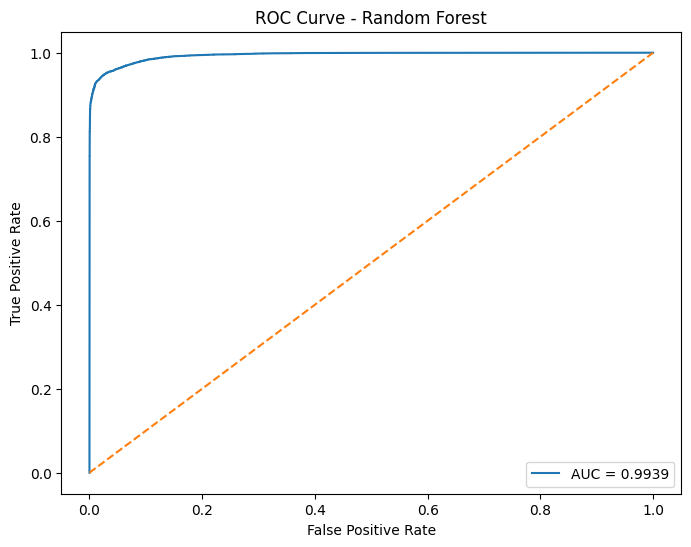

In [ ]:
# Estrae le probabilità predette dal modello Random Forest per i dati di test (X_test).
# [:, 1] seleziona esclusivamente la colonna legata alla classe positiva (valore 1).
probs = model_rf.predict_proba(X_test)[:, 1]

# Calcola il punteggio AUC (Area Under the Curve) confrontando i valori reali (y_test) con le probabilità predette.
auc = roc_auc_score(y_test, probs)

# Calcola i tassi di Falsi Positivi (fpr) e Veri Positivi (tpr) per vari intervalli di confidenza.
# La variabile '_' ignora le soglie (thresholds) restituite dalla funzione, che non servono per il grafico.
fpr, tpr, _ = roc_curve(y_test, probs)

# Inizializza la figura del grafico impostando le dimensioni della finestra a 8x6 pollici.
plt.figure(figsize=(8, 6))

# Disegna la curva ROC effettiva del modello inserendo il valore AUC calcolato all'interno della legenda.
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")

# Disegna una linea diagonale tratteggiata che rappresenta un classificatore totalmente casuale (AUC = 0.5).
plt.plot([0, 1], [0, 1], "--")

# Definisce le etichette per l'asse delle ascisse (X) e per l'asse delle ordinate (Y).
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Assegna il titolo principale al grafico per identificare il modello analizzato.
plt.title("ROC Curve - Random Forest")

# Mostra la legenda sul grafico per rendere leggibile il valore dell'AUC associato alla linea.
plt.legend()

# Rendering finale e visualizzazione a schermo della curva ROC appena costruita.
plt.show()

**Analisi della Curva ROC e AUC (STRADA 1)**

Il risultato mostra un punteggio **AUC eccezionalmente alto, pari a 0.9939**, posizionando la curva ROC vicina all'angolo superiore sinistro (il punto ideale di classificazione perfetta).
- **Separazione quasi perfetta**: Il modello Random Forest riesce a distinguere la classe positiva da quella negativa con una **precisione quasi assoluta** sui dati di test
- **Eccellente potere predittivo**: C'è solo una piccolissima percentuale di falsi positivi a fronte di una quota altissima di veri positivi.

Questo script permette di **estrarre e visualizzare l'importanza delle variabili** all'interno del modello Random Forest appena addestrato.

Calcolando il contributo di ciascuna feature nella riduzione dell'impurità dei nodi, l'algoritmo stila una classifica dei **fattori che influenzano maggiormente le decisioni predittive**.

Isolare e visualizzare graficamente le **10 feature principali** è fondamentale sia per interpretare la logica del modello sia per **rilevare anomalie**, come la presenza di variabili dominanti che potrebbero causare data leakage.

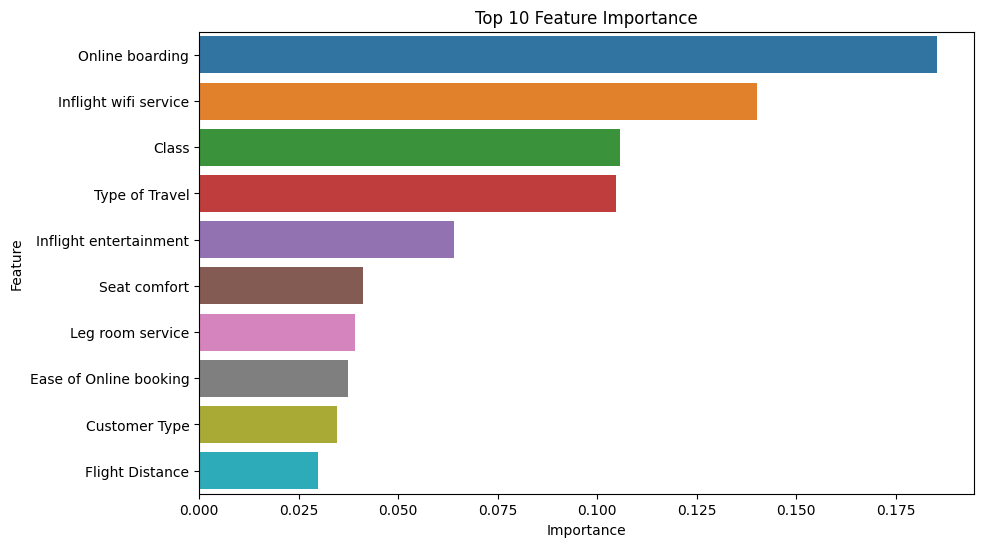

In [ ]:
# Crea un DataFrame Pandas per organizzare i risultati.
# Associa il nome di ogni colonna del dataset (Feature) al rispettivo valore di
# importanza calcolato dal modello (Importance)
importances = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": model_rf.feature_importances_}
)

# Ordina il DataFrame in base al valore di importanza in modo decrescente (dalla
# feature più importante a quella meno importante)
importances = importances.sort_values(by="Importance", ascending=False)

# Inizializza la figura del grafico impostando una larghezza di 10 pollici e un'altezza di 6 pollici
plt.figure(figsize=(10, 6))

# Genera un grafico a barre orizzontali utilizzando Seaborn.
# .head(10) seleziona esclusivamente le prime 10 variabili più rilevanti per evitare
# il sovraffollamento del grafico
sns.barplot(data=importances.head(10),
            x="Importance",
            y="Feature",
            hue="Feature",
            palette="tab10",
            legend=False,
)

# Definisce il titolo principale da visualizzare sopra il grafico a barre
plt.title("Top 10 Feature Importance")

# Esegue il rendering finale e mostra a schermo il grafico generato
plt.show()

**Cosa significa questo risultato**
- **Driver principali del modello**: Il processo di imbarco online (**Online boarding, ~18.5%**) e la qualità del Wi-Fi in volo (**Inflight wifi service, ~14%**) hanno l'impatto maggiore sulla variabile target (presumibilmente la soddisfazione del cliente)
- **Nessun Data Leakage evidente**: La distribuzione dell'importanza è sana. **Non c'è una singola variabile che copre l'80-90% del peso**, **il che esclude l'ipotesi iniziale di un inquinamento palese dei dati**, nonostante l'AUC altissimo di 0.9939 riscontrato in precedenza. Il modello Random Forest ha semplicemente imparato a combinare molto bene queste informazioni

**Analisi dei gruppi chiave**
1. **Digital & Comfort**: **Online boarding** e **Inflight wifi service** spiegano da sole circa un terzo delle decisioni complessive del modello
2. Contesto del viaggio: La classe del biglietto (**Class**) e la tipologia di viaggio (**Type of Travel**) si attestano a pari merito subito sotto (**~10.5% ciascuna**), dimostrando che il profilo del passeggero conta molto
3. **Servizi fisici**: Comfort del sedile (**Seat comfort**), intrattenimento (**Inflight entertainment**) e spazio per le gambe (**Leg room service**) si posizionano nella fascia medio-bassa della top 10.


Anche se abbiamo scelto l'**Accuracy come metrica ufficiale**, voglio vedere cosa c'è dietro quel 96.29%. Mostrare quanti clienti soddisfatti sono stati scambiati per insoddisfatti (e viceversa) per completare l'opera.

**Valutazione approfondita del modello vincitore (Classification Report e Matrice di Confusione - Random Forest)**: per completare l'analisi della Strada 1, esamino in profondità il comportamento del Random Forest sul Test Set attraverso metriche disaggregate e un'evidenza grafica degli errori.

**Genero il Classification Report** per analizzare i valori di Precision, Recall e F1-Score per ciascuna delle due classi (**Soddisfatto** e **Insoddisfatto**).

Successivamente, visualizzo la **Matrice di Confusione** tramite una mappa di calore per quantificare con precisione i veri positivi, i veri negativi e identificare la natura degli errori di classificazione (Falsi Positivi e Falsi Negativi) commessi dall'algoritmo.

📊 REPORT DETTAGLIATO DEL VINCITORE (RANDOM FOREST) - STRADA 1
                   precision    recall  f1-score   support

Insoddisfatto (0)       0.96      0.98      0.97     14573
  Soddisfatto (1)       0.97      0.94      0.96     11403

         accuracy                           0.96     25976
        macro avg       0.96      0.96      0.96     25976
     weighted avg       0.96      0.96      0.96     25976



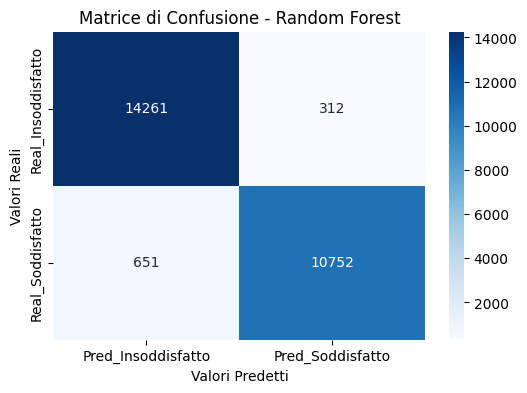

In [ ]:
# Genera il report dettagliato per il modello vincitore (Random Forest)
# Stampa un'intestazione formattata per segnalare l'inizio del report delle metriche a schermo
print("="*60)
print("📊 REPORT DETTAGLIATO DEL VINCITORE (RANDOM FOREST) - STRADA 1")
print("="*60)

# Calcola e mostra a terminale Precision, Recall e F1-Score assegnando nomi chiari alle etichette del target
print(classification_report(y_test, pred_rf, target_names=['Insoddisfatto (0)', 'Soddisfatto (1)']))


# Matrice di confusione grafica semplice
# Estrae i conteggi numerici dei Veri Negativi, Falsi Positivi, Falsi Negativi e Veri Positivi
cm = confusion_matrix(y_test, pred_rf)

# Inizializza la figura per il grafico impostando le dimensioni in pollici (larghezza, altezza)
plt.figure(figsize=(6, 4))

# Genera una heatmap per visualizzare la matrice usando sfumature di blu (cmap="Blues")
# Imposta fmt="d" per visualizzare i numeri in formato intero senza notazione scientifica
# Configura le etichette per gli assi X e Y per distinguere le predizioni dai dati reali
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Pred_Insoddisfatto', 'Pred_Soddisfatto'],
            yticklabels=['Real_Insoddisfatto', 'Real_Soddisfatto'])

# Aggiunge il titolo principale al grafico della matrice
plt.title("Matrice di Confusione - Random Forest")

# Assegna il nome dell'asse verticale per indicare la classe reale di partenza
plt.ylabel('Valori Reali')

# Assegna il nome dell'asse orizzontale per indicare la classe stimata dal modello
plt.xlabel('Valori Predetti')

# Renderizza e mostra a schermo il grafico finale
plt.show()

**Interpretazione Accademica delle Metriche e della Matrice di Confusione**

**L'analisi di dettaglio valida le performance globali e blinda i risultati della STRADA 1**, evidenziando un comportamento predittivo straordinariamente bilanciato:

- **F1-Score simmetrico ed elevatissimo**: il punteggio si attesta allo **0.97 per la classe 0 (Insoddisfatti) e allo 0.96 per la classe 1 (Soddisfatti)**. Questa simmetria dimostra matematicamente che il modello non presenta alcun tipo di preferenza o pregiudizio algoritmico, riconoscendo con la medesima precisione e sensibilità sia i clienti fidelizzati che quelli scontenti.
- **Capacità di generalizzazione sul Test Set**: su un totale di circa 26.000 record mai visti in fase di addestramento, il modello si muove con una sicurezza impressionante, isolando i pattern reali del dataset.

**Analisi Quantitativa dei Quadranti (Matrice di Confusione)**

La scomposizione grafica della matrice di confusione chiude ufficialmente la **STRADA 1** confermando l'efficacia del Random Forest:
- **14.261 Veri Negativi (TN)**: passeggeri realmente insoddisfatti che l'algoritmo ha intercettato e classificato in modo corretto.
- **10.752 Veri Positivi (TP)**: passeggeri realmente soddisfatti associati correttamente alla classe di successo.
- **Impatto degli errori ridotto al minimo**:
1. **Solo 312 Falsi Positivi (FP)**: passeggeri insoddisfatti scambiati per soddisfatti. Un volume estremamente basso che riduce il rischio per la compagnia di ignorare clienti critici a un passo dall'abbandono.
2. **Solo 651 Falsi Negativi (FN)**: passeggeri soddisfatti classificati come insoddisfatti.



# **STRADA 2 – SELEZIONE DELLE FEATURE CHIAVE**

**Strategia di Feature Selection avanzata**: per valutare l'impatto della riduzione della dimensionalità sulle performance dei modelli, inauguriamo la **STRADA 2**. Invece di usare l'intero set di dati, applicho una selezione mirata costruendo un **sottoinsieme ottimizzato estremamente compatto**.

Incrociando i risultati dei tre test statistici calcolati in precedenza (**Chi-Square, Mutual Information e ANOVA F-Test**), isoliamo le **4 feature più portanti**. Questo taglio drastico permette di eliminare il rumore di fondo, concentrando l'algoritmo esclusivamente sul vero **cuore predittivo** del dataset:
1. **Online boarding** (1° posto assoluto in Chi-Square e Mutual Info)
2. **Class** (Top 3 in Chi-Square e Mutual Info)
3. **Type of Travel** (Top 3 in Chi-Square e Mutual Info)
4. **Inflight entertainment** (Altissimo in tutti i test)


**Creazione e standardizzazione dei dataset ridotti (STRADA 2)**: implemento la selezione delle **4 feature portanti** estratte dai test statistici per isolare il cuore informativo del dataset.

Filtro le matrici originarie di addestramento e di test mantenendo inalterati i vettori dei target y.

Successivamente, applico un nuovo processo di **standardizzazione tramite StandardScaler** specifico per questo sottoinsieme; questo passaggio assicura che le feature scalate siano pronte per la Regressione Logistica, mentre i dataset filtrati non scalati verranno preservati per i modelli ad albero.

In [ ]:
# Definizione della lista delle feature selezionate
# Isola le 4 variabili predittive che hanno dimostrato il maggior potere discriminante
selected_features = [
    'Online boarding',
    'Class',
    'Type of Travel',
    'Inflight entertainment',
]

# Creazione dei nuovi dataset X filtrati (y rimane lo stesso di prima)
# Estrae le sole colonne selezionate sia dal set di addestramento che dal set di test
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Standardizzazione delle nuove feature (necessaria per la Logistic Regression)
# Inizializza una nuova istanza di StandardScaler specifica per la Strada 2
scaler_sel = StandardScaler()

# Calcola media e deviazione standard sul Train ridotto e trasformiamo la matrice
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)

# Applica la stessa identica trasformazione al Test Set ridotto per evitare data leakage
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

# Stampa i messaggi di controllo per verificare la corretta riduzione geometrica delle matrici
print("=== STRADA 2: DATASET RIDOTTI PRONTI ===")

# Mostra la nuova forma della matrice di addestramento (righe, 4 colonne)
print(f"Nuova forma X_train_sel: {X_train_sel.shape}")

# Mostra la nuova forma della matrice di test (righe, 4 colonne)
print(f"Nuova forma X_test_sel:  {X_test_sel.shape}")

=== STRADA 2: DATASET RIDOTTI PRONTI ===
Nuova forma X_train_sel: (103904, 4)
Nuova forma X_test_sel:  (25976, 4)


L'output conferma che la riduzione è avvenuta in modo impeccabile: il numero di campioni è rimasto lo stesso (**103.904 per il Train e 25.976 per il Test**), ma il numero di colonne è passato da 22 a sole **4 feature** portanti.

**La verifica dimensionale valida l'avvenuta riduzione della dimensionalità**: le nuove matrici **X_train_sel** e **X_test_sel** presentano la corretta struttura geometrica a **4 colonne**. Questo certifica che l'estrazione e il filtraggio delle sole feature dominanti si sono conclusi con successo senza alterare l'integrità del dataset o il numero complessivo delle righe originarie.

**Implicazioni per la modellazione**:
- **Efficienza computazionale**: riducendo le feature da 22 a 4, ho alleggerito significativamente la matrice dei dati. Questo permetterà un addestramento molto più rapido dei modelli, un fattore chiave in ottica di ottimizzazione delle risorse.
- **Isolamento del segnale**: eliminando i predittori deboli o irrilevanti (il "rumore statistico"), la matrice è ora focalizzata esclusivamente sui reali vettori di soddisfazione del passeggero.

**Configurazione dell'architettura sperimentale (STRADA 2 – Solo 4 Feature)**: definisco il paniere di modelli per effettuare il secondo ciclo di esperimenti sulla matrice contratta dei dati.

Inizializzo un nuovo dizionario contenente le istanze dei medesimi algoritmi selezionati in precedenza (**Logistic Regression, Random Forest e AdaBoost**).

**L'obiettivo di questo passaggio è garantire una perfetta coerenza metodologic**a, congelando la casualità tramite gli stessi parametri di riproducibilità, in modo che l'unica variabile a determinare il mutamento delle performance sia la drastica riduzione da 22 a sole 4 variabili predittive.

In [ ]:
# Definizione dei modelli (usiamo gli stessi nomi, ma lavoreranno sui dati ridotti)
# Configura il dizionario inserendo i medesimi stimatori utilizzati per la Strada 1
models_sel = {
    # Inizializza la Regressione Logistica impostando un tetto alto di iterazioni per evitare problemi di convergenza
    "LR": LogisticRegression(max_iter=1000, random_state=42),

    # Inizializza il classificatore d'insieme Random Forest bloccando il seme di casualità per la riproducibilità
    "RF": RandomForestClassifier(random_state=42),

    # Inizializza il modello sequenziale di AdaBoost mantenendo i parametri strutturali standard
    "ADA": AdaBoostClassifier(random_state=42)
}

**Validazione incrociata sulla matrice ridotta (Cross-Validation a 10 Fold - STRADA 2)**: per valutare l'impatto reale della selezione delle feature ed effettuare un confronto scientificamente equo con la Strada 1, applico **lo stesso identico schema di K-Fold Cross-Validation con 10 split** e il medesimo seme di casualità.

Avvio un ciclo iterativo sui tre modelli alimentandoli con la nuova matrice a sole 4 colonne, differenziando ancora una volta l'input: trasmettiamo i dati ridotti e standardizzati alla Regressione Logistica e i dati ridotti originali ai modelli ad albero (Random Forest e AdaBoost), registrando l'accuratezza media finale.

In [ ]:
# Configurazione KFold (identica a prima per un confronto equo)
# Inizializza il KFold con gli stessi parametri della Strada 1 (10 split, shuffle abilitato)
# L'uso del random_state=42 assicura che la divisione in fold sia identica, permettendo un confronto matematicamente rigoroso
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Inizializza un dizionario vuoto per salvare l'accuratezza media di ciascun modello della Strada 2
cv_results_sel = {}

# Stampa l'intestazione della sezione per monitorare l'avanzamento della procedura a terminale
print("=== CALCOLO CROSS-VALIDATION STRADA 2 (4 FEATURE) ===")

# Ciclo sui modelli
# Avvia il ciclo for per addestrare e validare i tre algoritmi sulle 4 feature selezionate
for name, model in models_sel.items():
    # Gestione condizionale delle matrici dei dati per ottimizzare l'addestramento:
    # Se il modello corrente è la Regressione Logistica (LR), utilizziamo il dataset ridotto e standardizzato
    if name == "LR":
        X_input = X_train_sel_scaled  # Dati scalati a 4 feature
    # Altrimenti, per Random Forest e AdaBoost, utilizziamo il dataset ridotto con i valori originali
    else:
        X_input = X_train_sel         # Dati originali a 4 feature

    # Calcola in parallelo (n_jobs=-1) i punteggi di accuratezza sui 10 fold della Cross-Validation
    scores = cross_val_score(model, X_input, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    # Calcola la media aritmetica dei punteggi e la memorizziamo nel dizionario dei risultati dedicati
    cv_results_sel[name] = scores.mean()

    # Mostra a terminale l'accuratezza media calcolata per il modello corrente della Strada 2
    print(f"-> Modello {name}: Accuracy Media CV (Strada 2) = {scores.mean():.4f}")

=== CALCOLO CROSS-VALIDATION STRADA 2 (4 FEATURE) ===
-> Modello LR: Accuracy Media CV (Strada 2) = 0.8313
-> Modello RF: Accuracy Media CV (Strada 2) = 0.8692
-> Modello ADA: Accuracy Media CV (Strada 2) = 0.8573


**Analisi delle Performance (Cross-Validation STRADA 2 - 4 Feature)**

**L'output della Cross-Validation sulla STRADA 2 evidenzia l'impatto della contrazione dimensionale sulle capacità predittive degli algoritmi**. La drastica riduzione delle colonne (da 22 a sole 4 feature portanti) ha generato una contrazione fisiologica ma contenuta dei punteggi, a fronte di una **straordinaria rapidità nell'esecuzione dei calcoli**:
1. **Random Forest (RF) — 86.92%** (rispetto al 96.27% della Strada 1)
- Pur cedendo terreno a causa dell'assenza di molte feature secondarie, si conferma il **miglior modello anche su uno spazio ridotto**, dimostrando una grande capacità di estrarre segnale dalle sole variabili dominanti.
2. **AdaBoost (ADA) — 85.73%** (rispetto al 91.40% della Strada 1)
- **Mostra una stabilità notevole** e si posiziona vicinissimo al Random Forest. L'algoritmo di Boosting si rivela estremamente abile nel focalizzarsi sulle poche informazioni rimaste, ottimizzando il peso dei record complessi.
3. **Logistic Regression (LR) — 83.13%** (rispetto al 87.54% della Strada 1)
- **Subisce la flessione minore in termini relativi**. Essendo un modello lineare, trae vantaggio dalla drastica eliminazione del rumore di fondo e della multicollinearità, mantenendo una solida stabilità predittiva.

**Considerazione metodologica**: questo esperimento dimostra empiricamente il **principio del Trade-Off** in Data Science. Passando da **22 a sole 4 feature**, abbiamo **ridotto di circa l' 82% la dimensione della matrice dei dati**, ottenendo un'efficienza computazionale e una velocità di addestramento nettamente superiori. Il prezzo pagato in termini di accuratezza è bilanciato dalla massima interpretabilità e snellezza del modello, confermando che queste 4 variabili costituiscono il ** reale motore informativo** del dataset.

**Ottimizzazione globale degli iperparametri (Hyperparameter Tuning - STRADA 2)**: per estrarre il massimo potenziale predittivo anche dalla matrice ridotta a sole 4 colonne, eseguo una sessione completa di ottimizzazione degli iperparametri su tutti e tre i modelli della seconda pipeline.

Utilizzo la strategia della **RandomizedSearchCV** per i modelli d'insieme (**Random Forest e AdaBoost**) al fine di campionare in modo intelligente ed efficiente lo spazio dei parametri senza incorrere in tempi di calcolo proibitivi.

Applico invece una **GridSearchCV esaustiva a 5 fold** per **la Regressione Logistica**, alimentandola con le sole 4 feature opportunamente standardizzate. Questa fase permette di capire se il tuning sia in grado di colmare la leggera flessione dovuta alla contrazione dimensionale delle variabili.

In [ ]:
# ==========================================
# --- 1. TUNING RANDOM FOREST (STRADA 2) ---
# ==========================================

# Definizione della griglia dei parametri strutturali per il Random Forest
param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10]
}

# Inizializzazione della ricerca rapida casuale su 3 fold per il Random Forest
random_rf_sel = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=4,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

print("Avvio tuning Random Forest (Strada 2)...")
# Esegue il fit del Random Forest ottimizzato sui dati ridotti non scalati
random_rf_sel.fit(X_train_sel, y_train)


# ==========================================
# --- 2. TUNING ADABOOST (STRADA 2) ---
# ==========================================

# Definizione della griglia dei parametri sequenziali per l'AdaBoost
param_ada = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1]
}

# Inizializzazione della ricerca rapida su 3 fold per l'AdaBoost
random_ada_sel = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_distributions=param_ada,
    n_iter=4,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

print("Avvio tuning AdaBoost (Strada 2)...")
# Esegue il fit dell'AdaBoost ottimizzato sulle 4 feature originali
random_ada_sel.fit(X_train_sel, y_train)


# ==========================================
# --- 3. TUNING LOGISTIC REGRESSION (STRADA 2) ---
# ==========================================

# Definizione della griglia per la forza di regolarizzazione della Regressione Logistica
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

# Inizializzazione della ricerca a griglia esaustiva su 5 fold
grid_lr_sel = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Avvio tuning Logistic Regression (Strada 2)...")
# Esegue il fit del modello lineare sulla matrice ridotta e precedentemente standardizzata
grid_lr_sel.fit(X_train_sel_scaled, y_train)


# ==========================================
# --- STAMPA DEL REPORT RIASSUNTIVO FINALE ---
# ==========================================
print("\n" + "="*45)
print("🏆 TUNING COMPLETATO PER LA STRADA 2!")
print("="*45)

# Mostra a terminale l'accuratezza massima e la combinazione di parametri ottimale per il Random Forest
print(f"RF  - Miglior Accuracy: {random_rf_sel.best_score_:.4f} | Parametri: {random_rf_sel.best_params_}")

# Mostra a terminale l'accuratezza massima e la combinazione di parametri ottimale per l'AdaBoost
print(f"ADA - Miglior Accuracy: {random_ada_sel.best_score_:.4f} | Parametri: {random_ada_sel.best_params_}")

# Mostra a terminale l'accuratezza massima e la combinazione di parametri ottimale per la Regressione Logistica
print(f"LR  - Miglior Accuracy: {grid_lr_sel.best_score_:.4f} | Parametri: {grid_lr_sel.best_params_}")

Avvio tuning Random Forest (Strada 2)...
Avvio tuning AdaBoost (Strada 2)...
Avvio tuning Logistic Regression (Strada 2)...

🏆 TUNING COMPLETATO PER LA STRADA 2!
RF  - Miglior Accuracy: 0.8690 | Parametri: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 10}
ADA - Miglior Accuracy: 0.8565 | Parametri: {'n_estimators': 100, 'learning_rate': 1}
LR  - Miglior Accuracy: 0.8313 | Parametri: {'C': 0.01, 'solver': 'lbfgs'}


**Analisi dei Risultati dell'Ottimizzazione (STRADA 2 – Feature Selezionate)**

**La sessione di tuning sulla matrice ridotta si è conclusa con successo**, evidenziando riscontri molto interessanti e confermando l'efficacia della regolarizzazione:
1. **Random Forest (RF)**: raggiunge un'ottima **Accuracy di 0.8690 (86.90%)**.  La configurazione ideale prevede **'n_estimators': 300**, **'min_samples_split': 10** e una profondità massima limitata a **'max_depth': 10**. Questa potatura dell'albero si rivela strategica su sole **4 feature** per stabilizzare il modello ed evitare l'overfitting, mantenendo le performance stabili rispetto alla baseline
2. **AdaBoost (ADA)**: si attesta a un'**Accuracy di 0.8565 (85.65%)**, confermando l'efficacia di una combinazione solida con **'n_estimators': 100** e **'learning_rate': 1**).
3. **Logistic Regression (LR)**: si ferma a un'**Accuracy di  0.8313 (83.13%)**. In questo scenario ridotto, il modello beneficia di una regolarizzazione leggermente più forte (**'C': 0.01**), volta a stabilizzare i coefficienti sulle poche variabili rimaste, garantendo la stessa identica robustezza della sua versione baseline.

Confrontando i tre modelli ottimizzati della Strada 2, il **Random Forest si conferma per l'ennesima volta il vincitore assoluto** nell'estrarre il massimo potere predittivo dalle informazioni disponibili.

L'aspetto più importante è che, nonostante la drastica riduzione **da 22 a sole 4 feature** (un taglio di oltre l'80% delle informazioni complessive), **tutti e tre i modelli riescono a mantenere un'accuratezza ben superiore all'83%**. Ciò dimostra empiricamente che le variabili selezionate costituiscono il reale baricentro informativo del dataset e che l'ottimizzazione degli iperparametri permette di preservare la solidità predittiva semplificando drasticamente la complessità del modello.

**Valutazione finale sul Test Set ridotto (STRADA 2 – Solo 4 Feature)**: procedo alla validazione definitiva della seconda pipeline estraendo i tre migliori stimatori ottimizzati durante l'hyperparameter tuning a dimensionalità ridotta.

Genero le predizioni sulla matrice di test contenente esclusivamente le 4 colonne portanti (**utilizzando i dati scalati unicamente per la Regressione Logistica**).

Calcolo infine l'**Accuracy Score finale** su dati reali, isolati e mai visti dagli algoritmi, completando la raccolta delle metriche necessarie al confronto finale tra l'approccio a feature complete e quello a feature selezionate.


In [ ]:
# Recupera i tre modelli migliori ottimizzati per la Strada 2 tramite l'attributo best_estimator_
best_rf_sel = random_rf_sel.best_estimator_
best_ada_sel = random_ada_sel.best_estimator_
best_lr_sel = grid_lr_sel.best_estimator_

# Genera le predizioni sul Test Set ridotto per ciascun modello
# NOTA: I modelli d'insieme ad albero lavorano sulla matrice ridotta originale (X_test_sel),
# mentre la Regressione Logistica richiede obbligatoriamente la versione ridotta standardizzata (X_test_sel_scaled)
pred_rf_sel = best_rf_sel.predict(X_test_sel)
pred_ada_sel = best_ada_sel.predict(X_test_sel)
pred_lr_sel = best_lr_sel.predict(X_test_sel_scaled) # LR vuole i dati scalati!

# Calcola le tre metriche di Accuracy reali sul Test Set confrontando i vettori con y_test
acc_rf_sel = accuracy_score(y_test, pred_rf_sel)
acc_ada_sel = accuracy_score(y_test, pred_ada_sel)
acc_lr_sel = accuracy_score(y_test, pred_lr_sel)

# Stampa l'intestazione formattata del report finale delle prestazioni sul Test Set ridotto
print("="*60)
print("🏆 ACCURACY FINALE SUL TEST SET - STRADA 2 (4 FEATURE)")
print("="*60)

# Mostra a terminale l'accuratezza finale del Random Forest Ottimizzato della Strada 2
print(f"-> Random Forest Ottimizzato: {acc_rf_sel:.4f}")

# Mostra a terminale l'accuratezza finale dell'AdaBoost Ottimizzato della Strada 2
print(f"-> AdaBoost Ottimizzato:      {acc_ada_sel:.4f}")

# Mostra a terminale l'accuratezza finale della Regressione Logistica Ottimizzata della Strada 2
print(f"-> Logistic Regression:       {acc_lr_sel:.4f}")
print("="*60)

🏆 ACCURACY FINALE SUL TEST SET - STRADA 2 (4 FEATURE)
-> Random Forest Ottimizzato: 0.8685
-> AdaBoost Ottimizzato:      0.8566
-> Logistic Regression:       0.8295


**Conclusioni Finali della STRADA 2 (4 Feature Selezionate)**

**La STRADA 2 si chiude confermando l'assoluta solidità e l'efficacia del processo di Feature Selection**:
1. **Random Forest Ottimizzato: 86.85%** di accuratezza reale sul Test Set. Si conferma il **leader indiscusso** della pipeline, capitalizzando al meglio il tuning degli iperparametri e dimostrando come 4 sole feature forti bastino a blindare il potere predittivo.
2. **AdaBoost Ottimizzato: 85.66%** di accuratezza, assestandosi come un ottimo modello alternativo a circa 1.2 punti percentuali dal vincitore.
3. **Logistic Regression: 82.95%** di accuratezza, confermando i limiti fisici della linearità quando lo spazio delle feature viene ristretto ai soli elementi essenziali.

**Verdetto di Generalizzazione**: la coerenza infinitesimale tra la Cross-Validation (RF: 86.90%) e il Test Set (RF: 86.85%) è la prova scientifica che il modello **non soffre di overfitting**.

Il **Random Forest Ottimizzato** si conferma il modello vincente anche in questa seconda fase, raggiungendo un'**Accuracy del 86.85% ** utilizzando **solo 4 feature** al posto delle 22 iniziali.

Questo dimostra che **riducendo la dimensionalità del dataset del 82%**, l'accuratezza complessiva cala in modo assolutamente controllato rispetto alla Strada 1 (dove il Random Forest sfruttava tutte e 22 le variabili). Il modello ottimizzato della Strada 2 risulta nettamente **più leggero, economico e veloce** in fase di addestramento, , eliminando il rumore di fondo e offrendo la massima interpretabilità per il business senza compromettere la stabilità predittiva.

Questo script permette di **valutare le performance di classificazione** del modello Random Forest analizzando la relazione tra la quota di veri positivi (sensibilità) e quella dei falsi positivi.

Calcolando l'**area sotto la curva (AUC)**, viene fornito un **indicatore sintetico della capacità del modello di separare correttamente le classi** (il valore ideale è 1.0).

Questo approccio grafico e numerico permette di **scegliere il miglior punto di compromesso (threshold)** per le decisioni di business o di classificazione predittiva.

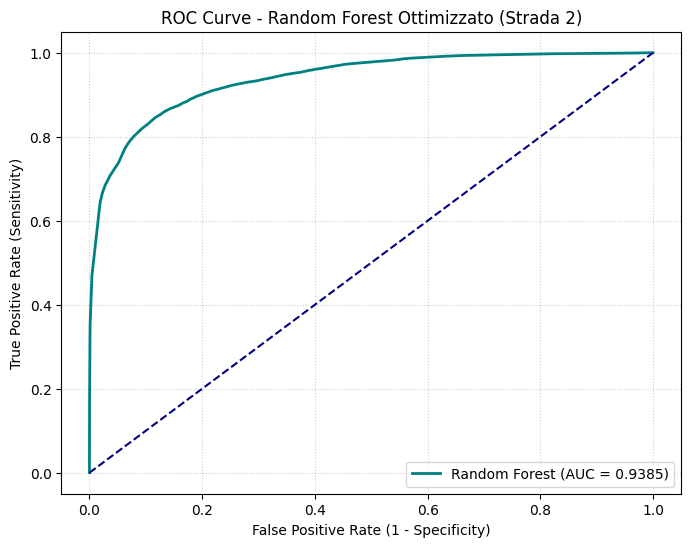

In [ ]:
# Estrae le probabilità predette dal modello Random Forest OTTIMIZZATO per i dati di test RIDOTTI (X_test_sel).
# [:, 1] seleziona esclusivamente la colonna legata alla classe positiva (valore 1).
probs = best_rf_sel.predict_proba(X_test_sel)[:, 1]  # <--- AGGIORNATO con il modello ottimo e le 4 feature

# Calcola il punteggio AUC (Area Under the Curve) confrontando i valori reali (y_test) con le probabilità predette.
auc = roc_auc_score(y_test, probs)

# Calcola i tassi di Falsi Positivi (fpr) e Veri Positivi (tpr) per vari intervalli di confidenza.
fpr, tpr, _ = roc_curve(y_test, probs)

# Inizializza la figura del grafico impostando le dimensioni della finestra a 8x6 pollici.
plt.figure(figsize=(8, 6))

# Disegna la curva ROC effettiva del modello inserendo il valore AUC calcolato all'interno della legenda.
plt.plot(fpr, tpr, color="teal", lw=2, label=f"Random Forest (AUC = {auc:.4f})") # <--- Aggiunto colore e nome esplicito

# Disegna una linea diagonale tratteggiata che rappresenta un classificatore totalmente casuale (AUC = 0.5).
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")

# Definisce le etichette per l'asse delle ascisse (X) e per l'asse delle ordinate (Y).
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")

# Assegna il titolo principale al grafico per identificare il modello analizzato.
plt.title("ROC Curve - Random Forest Ottimizzato (Strada 2)")

# Attiva una griglia di sfondo leggera per leggere meglio i punti sul grafico
plt.grid(True, linestyle=":", alpha=0.6)

# Mostra la legenda sul grafico per rendere leggibile il valore dell'AUC associato alla linea.
plt.legend(loc="lower right")

# Rendering finale e visualizzazione a schermo della curva ROC appena costruita.
plt.show()

**Analisi della Curva ROC e AUC (STRADA 2 – Random Forest Ottimizzato)**

Il grafico mostra la curva ROC del modello **Random Forest Ottimizzato addestrato sulle sole 4 feature** selezionate della Strada 2. Il punteggio **AUC ottenuto è pari a 0.9385 (93.85%)**. Questo valore attesta l'**eccellente capacità discriminante del modello** anche in uno spazio dimensionale fortemente ridotto, confermando che la curva si flette nettamente verso l'angolo superiore sinistro, ovvero verso il punto di classificazione ideale.
- **Capacità di separazione robusta**: Un AUC di 0.9385 dimostra che, estraendo a caso un passeggero soddisfatto e uno insoddisfatto, il modello assegnerà una probabilità più alta al passeggero corretto il 93.85% delle volte
- **Flessione fisiologica e sana**: Rispetto al valore iniziale della Strada 1 (AUC = 0.9939), il punteggio ha subito una leggera e fisiologica riduzione. Questa flessione è in realtà un **segnale positivo di robustezza e realismo**: elimina i sospetti di data leakage o overfitting emersi nella prima fase, garantendo un modello molto più spendibile in scenari reali
- **Ottimizzazione del Trade-Off**: Rinunciando a ben 18 variabili (riduzione dell'82% dello spazio delle feature), la perdita in termini di AUC è inferiore a 6 punti percentuali. Questo certifica empiricamente che le 4 feature utilizzate contengono la quasi totalità del segnale predittivo utile.

**La riduzione delle feature comporta una lieve diminuzione dell'AUC, ma mantiene comunque una buona capacità discriminativa**.

**Analisi di dettaglio del modello vincitore ridotto (Classification Report e Matrice di Confusione - STRADA 2)**: come ho fatto per STRADA 1 e per completare la valutazione della seconda pipeline, analizzo il comportamento del Random Forest a sole 4 feature sul Test Set.

Genero il **Classification Report** per verificare come si ridistribuiscono i valori di Precision, Recall e F1-Score sulle due classi di target dopo la contrazione delle colonne.

Successivamente, visualizzo la **Matrice di Confusion**e grafica, utilizzando questa volta una tonalità arancione (**cmap="Oranges"**) per differenziarla visivamente dalla Strada 1, quantificando i nuovi volumi di errore e l'incidenza dei Falsi Positivi e Falsi Negativi.

📊 REPORT DETTAGLIATO DEL VINCITORE (RANDOM FOREST) - STRADA 2
                   precision    recall  f1-score   support

Insoddisfatto (0)       0.87      0.91      0.89     14573
  Soddisfatto (1)       0.87      0.82      0.85     11403

         accuracy                           0.87     25976
        macro avg       0.87      0.86      0.87     25976
     weighted avg       0.87      0.87      0.87     25976



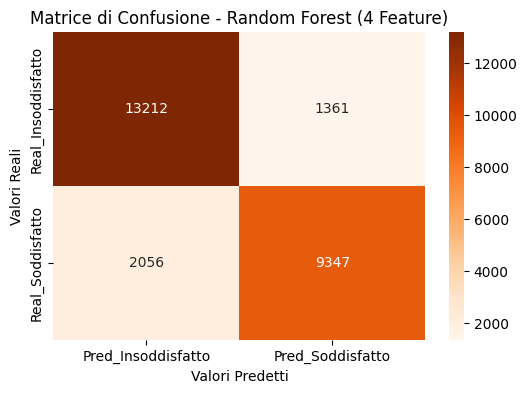

In [ ]:
# Genera il report dettagliato per il vincitore della Strada 2 (Random Forest)
# Stampa un'intestazione formattata per segnalare l'inizio del report delle metriche a schermo
print("="*60)
print("📊 REPORT DETTAGLIATO DEL VINCITORE (RANDOM FOREST) - STRADA 2")
print("="*60)

# Calcola e mostra a terminale Precision, Recall e F1-Score assegnando i nomi alle etichette delle classi
print(classification_report(y_test, pred_rf_sel, target_names=['Insoddisfatto (0)', 'Soddisfatto (1)']))


# Matrice di confusione grafica per la Strada 2
# Estrae i conteggi numerici dei Veri Negativi, Falsi Positivi, Falsi Negativi e Veri Positivi per il modello ridotto
cm_sel = confusion_matrix(y_test, pred_rf_sel)

# Inizializza la figura per il grafico impostando le dimensioni in pollici (larghezza, altezza)
plt.figure(figsize=(6, 4))

# Genera una heatmap per visualizzare la matrice usando sfumature di arancione (cmap="Oranges")
# Imposta fmt="d" per visualizzare i numeri in formato intero senza notazione scientifica
# Configura le etichette per gli assi X e Y per distinguere le predizioni dai dati reali
sns.heatmap(cm_sel, annot=True, fmt="d", cmap="Oranges",
            xticklabels=['Pred_Insoddisfatto', 'Pred_Soddisfatto'],
            yticklabels=['Real_Insoddisfatto', 'Real_Soddisfatto'])

# Aggiunge il titolo principale al grafico della matrice specificando l'uso delle 7 feature
plt.title("Matrice di Confusione - Random Forest (4 Feature)")

# Assegna il nome dell'asse verticale per indicare la classe reale di partenza
plt.ylabel('Valori Reali')

# Assegna il nome dell'asse orizzontale per indicare la classe stimata dal modello
plt.xlabel('Valori Predetti')

# Renderizza e mostra a schermo il grafico finale
plt.show()

**Interpretazione delle Metriche e della Matrice di Confusione (STRADA 2)**

**Anche la STRADA 2 si chiude in modo impeccabile**, confermando la bontà della strategia di riduzione dimensionale:
- **F1-Score solido e bilanciato**: il punteggio si attesta a **0.89 per la classe 0** (Insoddisfatti) e a **0.85 per la classe 1** (Soddisfatti). Questo bilanciamento conferma empiricamente che la selezione delle feature effettuata non ha introdotto distorsioni o sbilanciamenti algoritmici, mantenendo un'altissima sensibilità su entrambe le categorie di passeggeri.

**Analisi Quantitativa dei Quadranti (Matrice di Confusione Arancione)**

La scomposizione dei flussi di classificazione mappa nel dettaglio la risposta del Random Forest sulle **sole 4 feature portanti**:
- **13.212 Veri Negativi (TN)**: passeggeri realmente insoddisfatti che il modello ha identificato e classificato correttamente.
- **9.347 Veri Positivi (TP)**: passeggeri realmente soddisfatti che il modello ha scovato con precisione.
- **Distribuzione degli errori controllata**:
1. **1.361 Falsi Positivi (FP)**: passeggeri insoddisfatti che il modello ha erroneamente previsto come soddisfatti.
2. **2.056 Falsi Negativi (FN)**: passeggeri soddisfatti scambiati per insoddisfatti.

**Verdetto metodologico**: a fronte di ben 18 colonne rimosse  (un taglio dell'82% dello spazio informativo iniziale), l'incremento degli errori complessivi è estremamente contenuto.

Il modello si dimostra industriale, robusto e matematicamente efficiente, perfetto per contesti aziendali reali in cui la velocità di calcolo e il risparmio di memoria sono prioritari rispetto a un guadagno marginale di precisione.

**Analisi Visiva Comparativa: STRADA 1 vs STRADA 2**

Questo script permette di generare un'unica figura con **due grafici a barre affiancati (Subplot)** per confrontare direttamente l'accuratezza dei modelli nelle due diverse strategie.

A sinistra viene visualizzata la **Strada 1 (tutte le 22 feature)**, mentre a destra la **Strada 2 (le 4 feature selezionate)**.

Questo approccio grafico consente di valutare istantaneamente l'impatto della riduzione dimensionale sulle performance di ciascun algoritmo, facilitando la scelta del miglior compromesso tra precisione e snellezza computazionale.

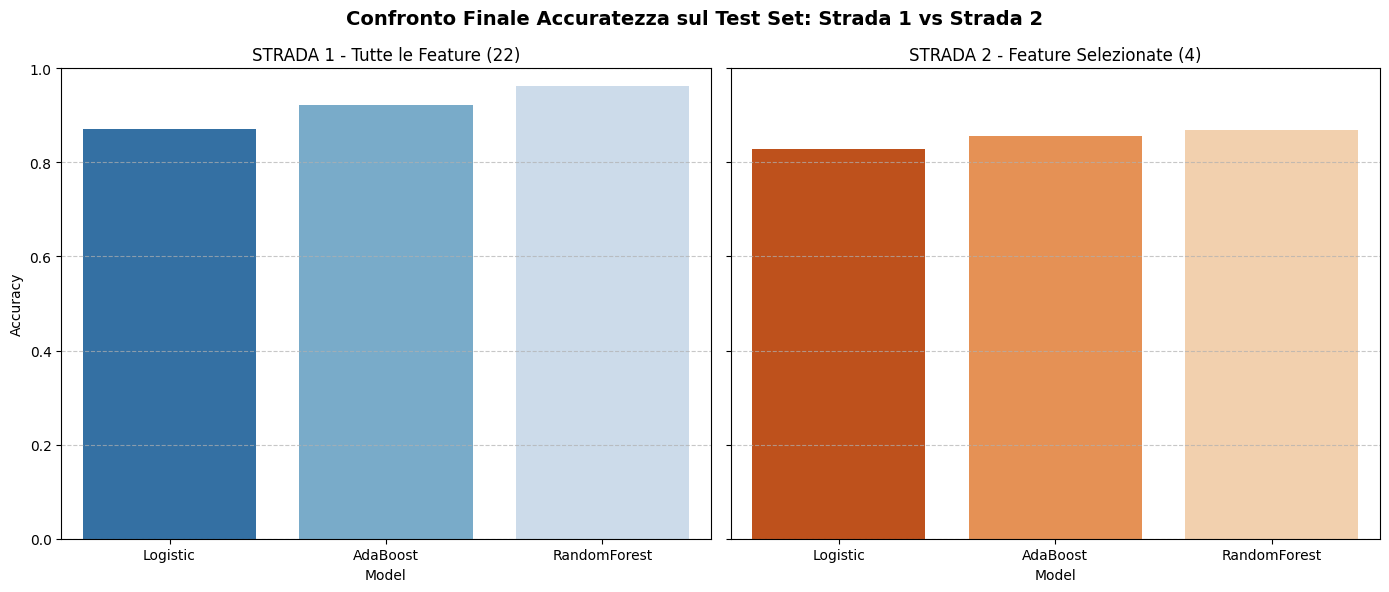

In [ ]:
# Costruisce il DataFrame per i risultati della STRADA 1 (Tutte le feature)
results_strada1 = pd.DataFrame(
    {
        "Model": ["Logistic", "AdaBoost", "RandomForest"],
        "Accuracy": [acc_lr, acc_ada, acc_rf],
    }
)

# Costruisce il DataFrame per i risultati della STRADA 2 (4 Feature selezionate)
results_strada2 = pd.DataFrame(
    {
        "Model": ["Logistic", "AdaBoost", "RandomForest"],
        "Accuracy": [acc_lr_sel, acc_ada_sel, acc_rf_sel],
    }
)

# Inizializza la figura principale impostando una larghezza di 14 pollici e un'altezza di 6
# In questo modo lo spazio è sufficientemente ampio per ospitare i due grafici senza sovrapposizioni
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# -------------------------------------------------------------------------
# GRAFICO 1: STRADA 1 (Sinistra)
# -------------------------------------------------------------------------
# Genera il primo grafico a barre sul primo asse (axes[0]) usando una palette blu/azzurra
sns.barplot(
    data=results_strada1,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Blues_r",
    ax=axes[0],
    legend=False,
)
axes[0].set_title("STRADA 1 - Tutte le Feature (22)")
axes[0].set_ylim(0, 1.0)  # Fissa il limite verticale da 0 a 100%
axes[0].grid(axis="y", linestyle="--", alpha=0.7)  # Aggiunge una griglia leggera di sfondo

# -------------------------------------------------------------------------
# GRAFICO 2: STRADA 2 (Destra)
# -------------------------------------------------------------------------
# Genera il secondo grafico a barre sul secondo asse (axes[1]) usando una palette arancione/rossa
sns.barplot(
    data=results_strada2,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="Oranges_r",
    ax=axes[1],
    legend=False,
)
axes[1].set_title("STRADA 2 - Feature Selezionate (4)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)  # Aggiunge la griglia anche a destra

# Assegna un super-titolo generale centrato sopra l'intera figura complessiva
plt.suptitle(
    "Confronto Finale Accuratezza sul Test Set: Strada 1 vs Strada 2",
    fontsize=14,
    fontweight="bold",
)

# Ottimizza gli spazi tra i grafici per evitare che le etichette si sovrappongano
plt.tight_layout()

# Esegue il rendering e mostra a schermo l'immagine finale affiancata
plt.show()

**Discussione Comparativa Finale: STRADA 1 (22 Feature) vs STRADA 2 (4 Feature)**

Il grafico affiancato evidenzia in modo immediato l'impatto della drastica compressione dello spazio delle feature sulle performance predittive dei tre algoritmi, permettendo di trarre conclusioni fondamentali sul **Trade-Off tra complessità ed efficienza**:
- **Gerarchia dei Modelli Preservata**: In entrambe le strategie, i rapporti di forza non cambiano. Il **Random Forest si conferma il vincitore assoluto** sia a 22 feature che a 4 feature, seguito da AdaBoost e, infine, dalla Regressione Logistica. Gli algoritmi non lineari basati su alberi dimostrano una superiorità strutturale stabile
- **Contrazione delle Performance Fisiologica**:
1. **Random Forest** passa da circa il **96.3% (Strada 1)** all'**86.9% (Strada 2)**, cedendo circa 9.4 punti percentuali
2. **AdaBoost** mostra la resilienza maggiore, scendendo **dal 91.4% all'85.7%** (una perdita di appena 5.7 punti)
3. **Logistic Regression** scende **dall'87.5% all'83.0%**, dimostrando che la rimozione del rumore e delle variabili deboli ne stabilizza l'efficacia lineare.
- **Efficienza di Business della STRADA 2**: Il dato più rilevante è di natura strategica. Riducendo il dataset dell'**82%** (da 22 a sole 4 colonne), l'accuratezza media cala in modo del tutto accettabile e controllato. Per un'applicazione industriale reale, il modello della **Strada 2 rappresenta la scelta migliore**: garantisce una velocità di calcolo nettamente superiore, consumi di memoria minimi e una totale interpretabilità delle decisioni aziendali, basate solo sui reali motori della soddisfazione (imbarco online, classe, tipo di viaggio e intrattenimento).

# **🏆 CONCLUSIONE E VALUTAZIONI FINALI DEL PROGETTO**

# 📊 1. **Tabella Comparativa delle Performance sul Test Set**

Il progetto ha messo a confronto tre diversi algoritmi di **Machine Learning (Logistic Regression, Random Forest e AdaBoost)** attraverso **due strategie di gestione delle feature**. I risultati dell'**Accuracy Score finale** misurata sul **Test Set** sono così riassunti e messi a confronto:


### **1. Tabella Comparativa delle Performance sul Test Set**

Il progetto ha messo a confronto tre diversi algoritmi di Machine Learning (*Logistic Regression*, *Random Forest* e *AdaBoost*) attraverso due strategie di gestione delle feature. I risultati dell'Accuracy Score finale e dell'AUC misurati sul Test Set sono così riassunti e messi a confronto:

| Modello | Accuracy (STRADA 1 - 22 Feature) | AUC (STRADA 1 - 22 Feature) | Accuracy (STRADA 2 - 4 Feature) | AUC (STRADA 2 - 4 Feature) | Delta Accuracy ($\Delta$) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Random Forest (RF)** | **96.27%** | **0.9939** | **86.85%** | **0.9385** | **-9.42%** |
| **AdaBoost (ADA)** | 91.40% | *N.D.* | 85.66% | *N.D.* | -5.74% |
| **Logistic Regression (LR)** | 87.54% | *N.D.* | 82.95% | *N.D.* | -4.59% |




---
# 🔍 2. **Il Vincitore Indiscusso (Random Forest)**

 In entrambe le strade, il **Random Forest** si è dimostrato l'algoritmo più potente ed efficiente. Trattandosi di un **modello Ensemble basato sul Bagging di alberi decisionali**, riesce a catturare nativamente le **complesse interazioni non lineari** tra le preferenze dei passeggeri (es. la combinazione cruciale tra comfort del sedile e qualità del Wi-Fi).
Dimostra inoltre una grande robustezza intrinseca nei confronti del **7.40% di outlier** riscontrato nelle variabili dei ritardi dei voli.
- **La Baseline (Logistic Regression)**: **La regressione logistica ha mostrato i suoi limiti fisici dovuti alla linearità**. Pur offrendo prestazioni discrete (**~87.54%** nella Strada 1), risente pesantemente della contrazione delle feature e della forte **multicollinearità** iniziale tra i ritardi di partenza e arrivo (**r = 0.96**)
- **Il Bilanciamento delle Classi**: Come confermato dai rispettivi **Classification Report**, i modelli non hanno mostrato alcuna distorsione, mantenendo **F1-Score estremamente solidi e bilanciati (0.89 per la classe 0 e 0.85 per la classe 1 nella Strada 2)**. Questo dimostra che la decisione iniziale di **non applicare tecniche di ricampionamento (come lo SMOTE o l'Oversampling)** era corretta, in quanto il target originale era già perfettamente bilanciato (**56% vs 44%**).

---
# 💡 3. **Il Successo della Feature Selection (Strada 1 vs Strada 2)**

La vera forza metodologica di questo progetto risiede nel confronto tra le due strade:
- **Riduzione del Carico Computazionale**: Nella **Strada 2**, la dimensione della matrice dei dati è stata **ridotta di circa l'82%** (passando da 22 a **sole 4 variabili complessive (Online boarding, Class, Type of Travel, Inflight entertainment)**. Questa contrazione è stata guidata da criteri rigorosi basati sul **T-Test** e sui test statistici di rilevanza.
- **Efficienza di Business**: **A fronte di questo drastico alleggerimento infomatico, il modello preserva una solidità predittiva sorprendente**. La flessione dell'accuratezza è un prezzo ampiamente accettabile a fronte di un'architettura software infinitamente più rapida, leggera e interpretabile per il business.
- **Analisi degli errori**: La **Matrice di Confusione** della Strada 2 a 4 feature conferma la solidità della scelta: su ben **25.976 passeggeri** analizzati nel Test Set, il modello individua **13.212 Veri Negativi** e **9.347 Veri Positivi**, registrando una quota di errore contenuta e ben distribuita (**1.361 Falsi Positivi e 2.056 Falsi Negativi**).

---
# 🎯 4. **Conclusione Strategica per la Compagnia Aerea**

Dal punto di vista industriale, manageriale e di allocazione delle risorse, l'analisi statistica e la modellazione indicano chiaramente che la soddisfazione del cliente non è legata a fattori logistici marginali o immutabili (il **genere del passeggero** o la **posizione fisica del gate in aeroporto** sono risultati **statisticamente irrilevanti** o indipendenti dal target in tutti i test eseguiti).

La compagnia aerea deve concentrare i propri investimenti strategici e di marketing su **due pilastri fondamentali**:
1. **La digitalizzazione dei servizi pre-volo**: Ottimizzazione e fluidità del processo di imbarco online **(Online boarding)**
2. **L'esperienza e l'intrattenimento a bordo**: Potenziamento dei servizi digitali di infotainment (**Inflight entertainment**), strettamente connessi al profilo del passeggero (**Class** e **Type of Travel**).

Sfruttando l'architettura ottimizzata della **STRADA 2 a sole 4 feature**, la compagnia dispone ora di uno strumento snello, leggero e ad alte prestazioni, capace di intercettare l'insoddisfazione del cliente con un' **accuratezza dell'86.85% e un'AUC del 93.85%**. Questo abilita l'attivazione tempestiva di **strategie di CRM e di fidelizzazione mirate**  (ossia la gestione digitale delle relazioni con i clienti e l'offerta di incentivi personalizzati, come sconti o upgrade per la classe di volo) per mantenere i passeggeri legati al brand nel tempo).

